# G — Spatial Heatmaps: Temperature Distribution within Each Area

2D grid maps showing the spatial pattern of temperature at peak hour.  
Reveals **where** cooling occurs (vegetated patches, shaded zones, exposed surfaces).

**Saves to** `../figures/G_spatial_maps/`

In [1]:
import sys
from pathlib import Path
NB_DIR = Path.cwd() if Path.cwd().name == 'notebooks' else Path.cwd() / 'notebooks'
sys.path.insert(0, str(NB_DIR))
from config import *
import matplotlib.colors as mcolors
from mpl_toolkits.axes_grid1 import make_axes_locatable

SAVE_DIR = FIGURES_DIR / 'G_spatial_maps'
SAVE_DIR.mkdir(parents=True, exist_ok=True)
print('Setup done. Saving to:', SAVE_DIR)

Config loaded.  ROOT=/home/mourouzidou/Downloads/Anastasia
Output dir : /home/mourouzidou/Downloads/Anastasia/output
Figures dir: /home/mourouzidou/Downloads/Anastasia/figures
Setup done. Saving to: /home/mourouzidou/Downloads/Anastasia/figures/G_spatial_maps


In [2]:
print('Loading atmosphere...'); atm_raw = load_csvs('atmosphere')
print('Loading surface...');    srf_raw = load_csvs('surface')
SURF_TEMP_COL, SURF_ALB_COL = detect_surface_cols(srf_raw)
print(f'Surface temp col: {SURF_TEMP_COL}')

atm = atm_raw[atm_raw[BUILDING_COL] == 0].copy() if BUILDING_COL in atm_raw.columns else atm_raw.copy()
srf = srf_raw.copy()
print(f'atm outdoor: {len(atm):,} rows  |  srf: {len(srf):,} rows')

Loading atmosphere...
  Shaded_15Aug_atmosphere.parquet  →  260,000 rows
  Shaded_15Feb_atmosphere.parquet  →  260,000 rows
  Shaded_15Nov_atmosphere.parquet  →  510,000 rows
  Shaded_31Mar_atmosphere.parquet  →  260,000 rows
  Waterfront_15Aug_atmosphere.parquet  →  260,000 rows
  Waterfront_15Feb_atmosphere.parquet  →  260,000 rows
  Waterfront_15Nov_atmosphere.parquet  →  260,000 rows
  Waterfront_31Mar_atmosphere.parquet  →  260,000 rows
  Zefkseidos_15Aug_atmosphere.parquet  →  300,000 rows
  Zefkseidos_15Feb_atmosphere.parquet  →  260,000 rows
  Zefkseidos_15Nov_atmosphere.parquet  →  260,000 rows
  Zefkseidos_31Mar_atmosphere.parquet  →  260,000 rows
Loading surface...
  Shaded_15Aug_surface.parquet  →  250,000 rows
  Shaded_15Feb_surface.parquet  →  250,000 rows
  Shaded_15Nov_surface.parquet  →  250,000 rows
  Shaded_31Mar_surface.parquet  →  250,000 rows
  Waterfront_15Aug_surface.parquet  →  250,000 rows
  Waterfront_15Feb_surface.parquet  →  250,000 rows
  Waterfront_15Nov_

## G1 — Air temperature spatial map (summer peak, 14:00)
One panel per area. Colour = air temperature at ground level, outdoor cells only.

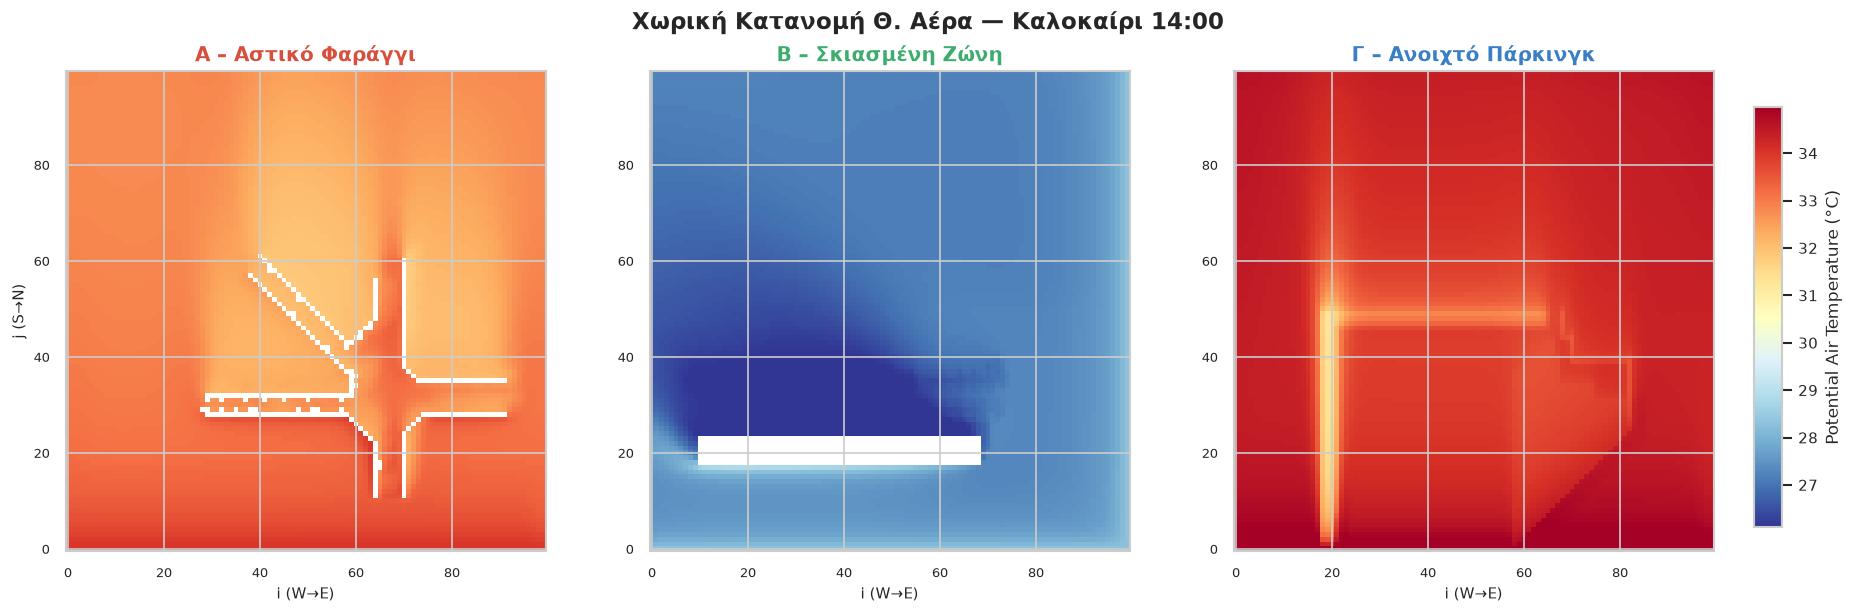

Saved G1_air_spatial_summer_14h.png


In [3]:
GR_AREA = {
    'Zefkseidos': 'Α – Αστικό Φαράγγι',
    'Shaded':     'Β – Σκιασμένη Ζώνη',
    'Waterfront': 'Γ – Ανοιχτό Πάρκινγκ',
}

def spatial_map(df, col, hour, date, title, fname,
                cmap='RdYlBu_r', vmin=None, vmax=None):
    """
    3-panel spatial heatmap: one per area at a fixed hour/date.
    Uses (i, j) grid indices to reconstruct the 2D map.
    """
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    fig.subplots_adjust(left=0.04, right=0.92, top=0.88, bottom=0.08, wspace=0.12)
    fig.suptitle(title, fontsize=14, fontweight='bold')

    # Determine shared colour scale from all areas
    if vmin is None or vmax is None:
        all_vals = []
        for area in AREA_ORDER:
            sub = df[(df['area'] == area) & (df['date'] == date) & (df['hour'] == hour)]
            if len(sub): all_vals.append(sub[col].dropna())
        if all_vals:
            combined = pd.concat(all_vals)
            vmin = vmin or combined.quantile(0.02)
            vmax = vmax or combined.quantile(0.98)

    im = None
    for ax, area in zip(axes, AREA_ORDER):
        sub = df[(df['area'] == area) & (df['date'] == date) & (df['hour'] == hour)]
        if len(sub) == 0:
            ax.text(0.5, 0.5, 'Χωρίς δεδομένα', ha='center', va='center',
                    transform=ax.transAxes, color='grey')
            continue

        grid = sub.pivot_table(index='j', columns='i', values=col, aggfunc='mean')
        im = ax.imshow(
            grid.values,
            origin='lower',
            cmap=cmap,
            vmin=vmin, vmax=vmax,
            aspect='equal',
            interpolation='nearest',
        )

        ax.set_title(GR_AREA[area], fontsize=12, fontweight='bold',
                     color=AREA_COLORS[area])
        ax.set_xlabel('i (W→E)', fontsize=9)
        ax.set_ylabel('j (S→N)' if area == AREA_ORDER[0] else '', fontsize=9)
        ax.tick_params(labelsize=8)

    # Shared colourbar on the right
    if im is not None:
        cbar_ax = fig.add_axes([0.93, 0.12, 0.015, 0.70])
        cb = fig.colorbar(im, cax=cbar_ax)
        cb.set_label(col, fontsize=10)
        cb.ax.tick_params(labelsize=9)

    fig.savefig(SAVE_DIR / fname, dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved', fname)


spatial_map(atm, AIR_TEMP_COL, hour=14, date='15Aug',
            title='Χωρική Κατανομή Θ. Αέρα — Καλοκαίρι 14:00',
            fname='G1_air_spatial_summer_14h.png')

## G2 — Surface temperature spatial map (summer peak, 13:00)

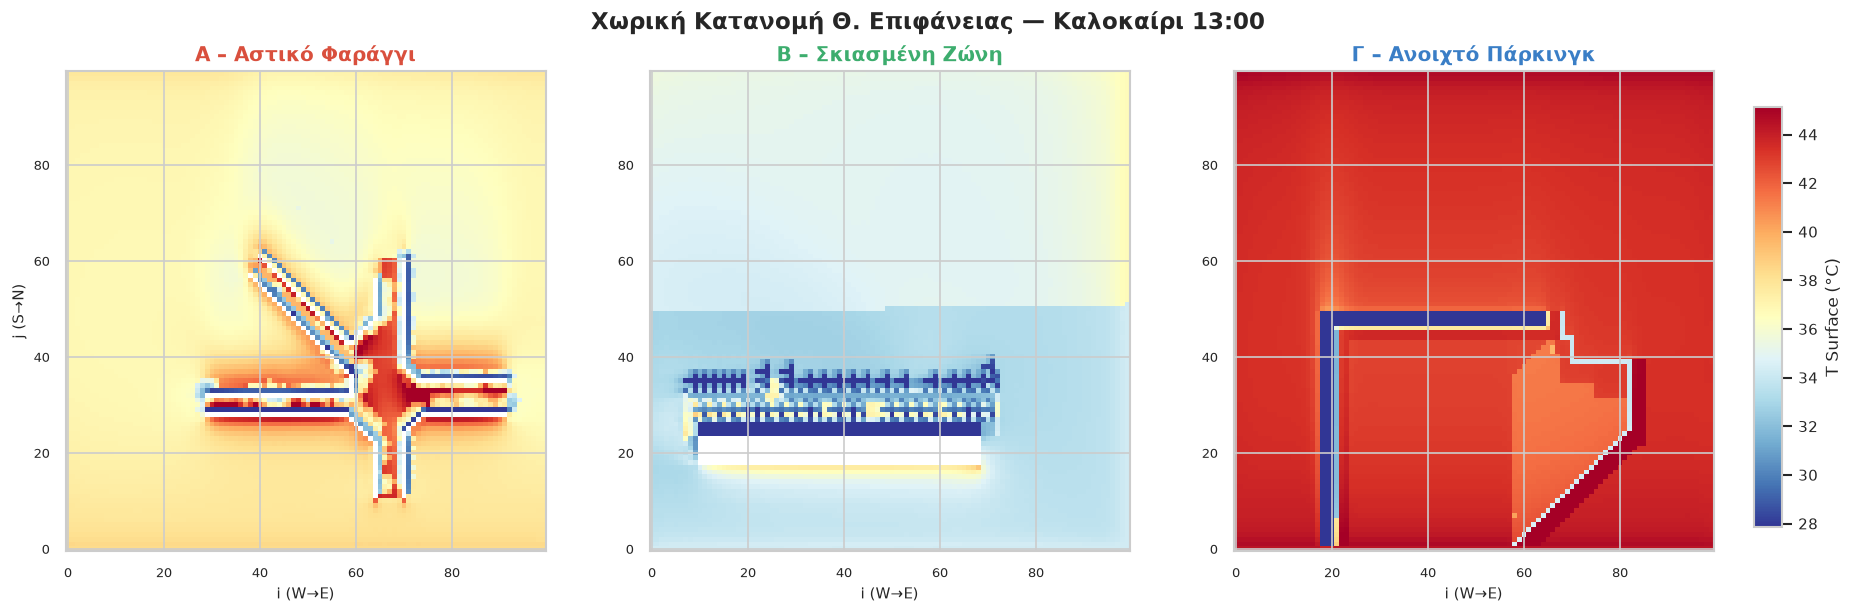

Saved G2_surface_spatial_summer_13h.png


In [4]:
spatial_map(srf, SURF_TEMP_COL, hour=13, date='15Aug',
            title='Χωρική Κατανομή Θ. Επιφάνειας — Καλοκαίρι 13:00',
            fname='G2_surface_spatial_summer_13h.png')

## G3 — All seasons: air temperature spatial maps (14:00)
3 areas × 4 seasons grid — shows how the spatial pattern changes across seasons.

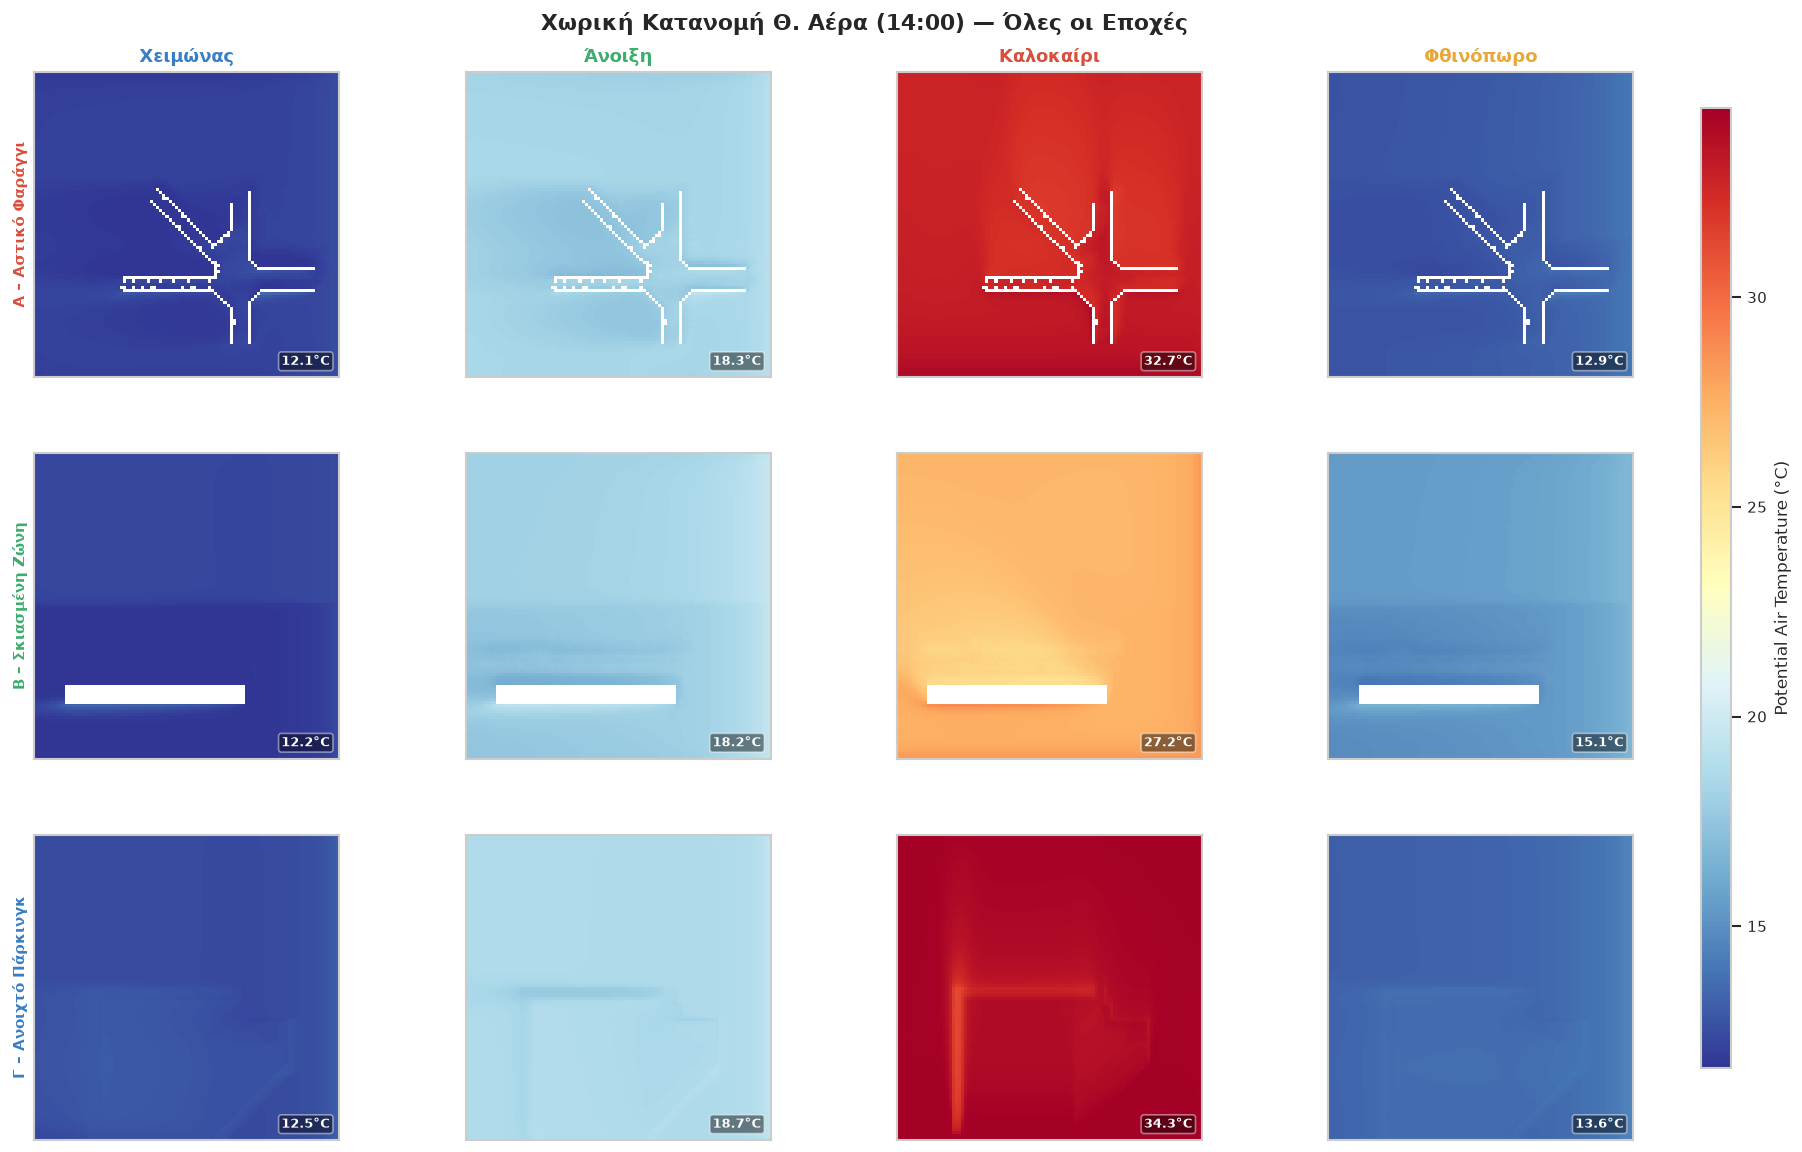

Saved G3_air_spatial_allseasons.png  (scale: 11.6°C – 34.5°C)


In [8]:
GR_DATE = {'15Feb': 'Χειμώνας', '31Mar': 'Άνοιξη', '15Aug': 'Καλοκαίρι', '15Nov': 'Φθινόπωρο'}

def spatial_grid(df, col, hour, title, fname, cmap='RdYlBu_r'):
    """3 (areas) × 4 (seasons) grid of spatial maps with a single global colour scale."""
    fig, axes = plt.subplots(len(AREA_ORDER), len(DATE_ORDER),
                             figsize=(17, 10))
    fig.subplots_adjust(left=0.07, right=0.90, top=0.93, bottom=0.04,
                        wspace=0.08, hspace=0.25)
    fig.suptitle(title, fontsize=13, fontweight='bold')

    # ── Single global colour scale across ALL areas and ALL seasons ───────────
    all_vals = df[(df['hour'] == hour)][col].dropna()
    vmin = all_vals.quantile(0.02)
    vmax = all_vals.quantile(0.98)

    im = None
    for r, area in enumerate(AREA_ORDER):
        for c, date in enumerate(DATE_ORDER):
            ax = axes[r, c]
            sub = df[(df['area'] == area) & (df['date'] == date) & (df['hour'] == hour)]

            if r == 0:
                ax.set_title(GR_DATE[date], fontsize=11, fontweight='bold',
                             color=DATE_COLORS[date])
            if c == 0:
                ax.set_ylabel(GR_AREA[area], fontsize=9, fontweight='bold',
                              color=AREA_COLORS[area])

            if len(sub) == 0:
                ax.text(0.5, 0.5, '—', ha='center', va='center',
                        transform=ax.transAxes, color='grey')
                ax.set_xticks([]); ax.set_yticks([])
                continue

            grid = sub.pivot_table(index='j', columns='i', values=col, aggfunc='mean')
            im = ax.imshow(grid.values, origin='lower', cmap=cmap,
                           vmin=vmin, vmax=vmax, aspect='equal',
                           interpolation='nearest')
            ax.set_xticks([]); ax.set_yticks([])

            # Median annotation
            med = sub[col].median()
            ax.text(0.97, 0.03, f'{med:.1f}°C', transform=ax.transAxes,
                    ha='right', va='bottom', fontsize=8, color='white',
                    fontweight='bold',
                    bbox=dict(boxstyle='round,pad=0.2', fc='black', alpha=0.45))

    # Single shared colourbar
    if im is not None:
        cbar_ax = fig.add_axes([0.91, 0.10, 0.015, 0.80])
        cb = fig.colorbar(im, cax=cbar_ax)
        cb.set_label(col, fontsize=10)
        cb.ax.tick_params(labelsize=9)

    fig.savefig(SAVE_DIR / fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved {fname}  (scale: {vmin:.1f}°C – {vmax:.1f}°C)')


spatial_grid(atm, AIR_TEMP_COL, hour=14,
             title='Χωρική Κατανομή Θ. Αέρα (14:00) — Όλες οι Εποχές',
             fname='G3_air_spatial_allseasons.png')


## G4 — Surface temperature spatial grid (all seasons, 13:00)

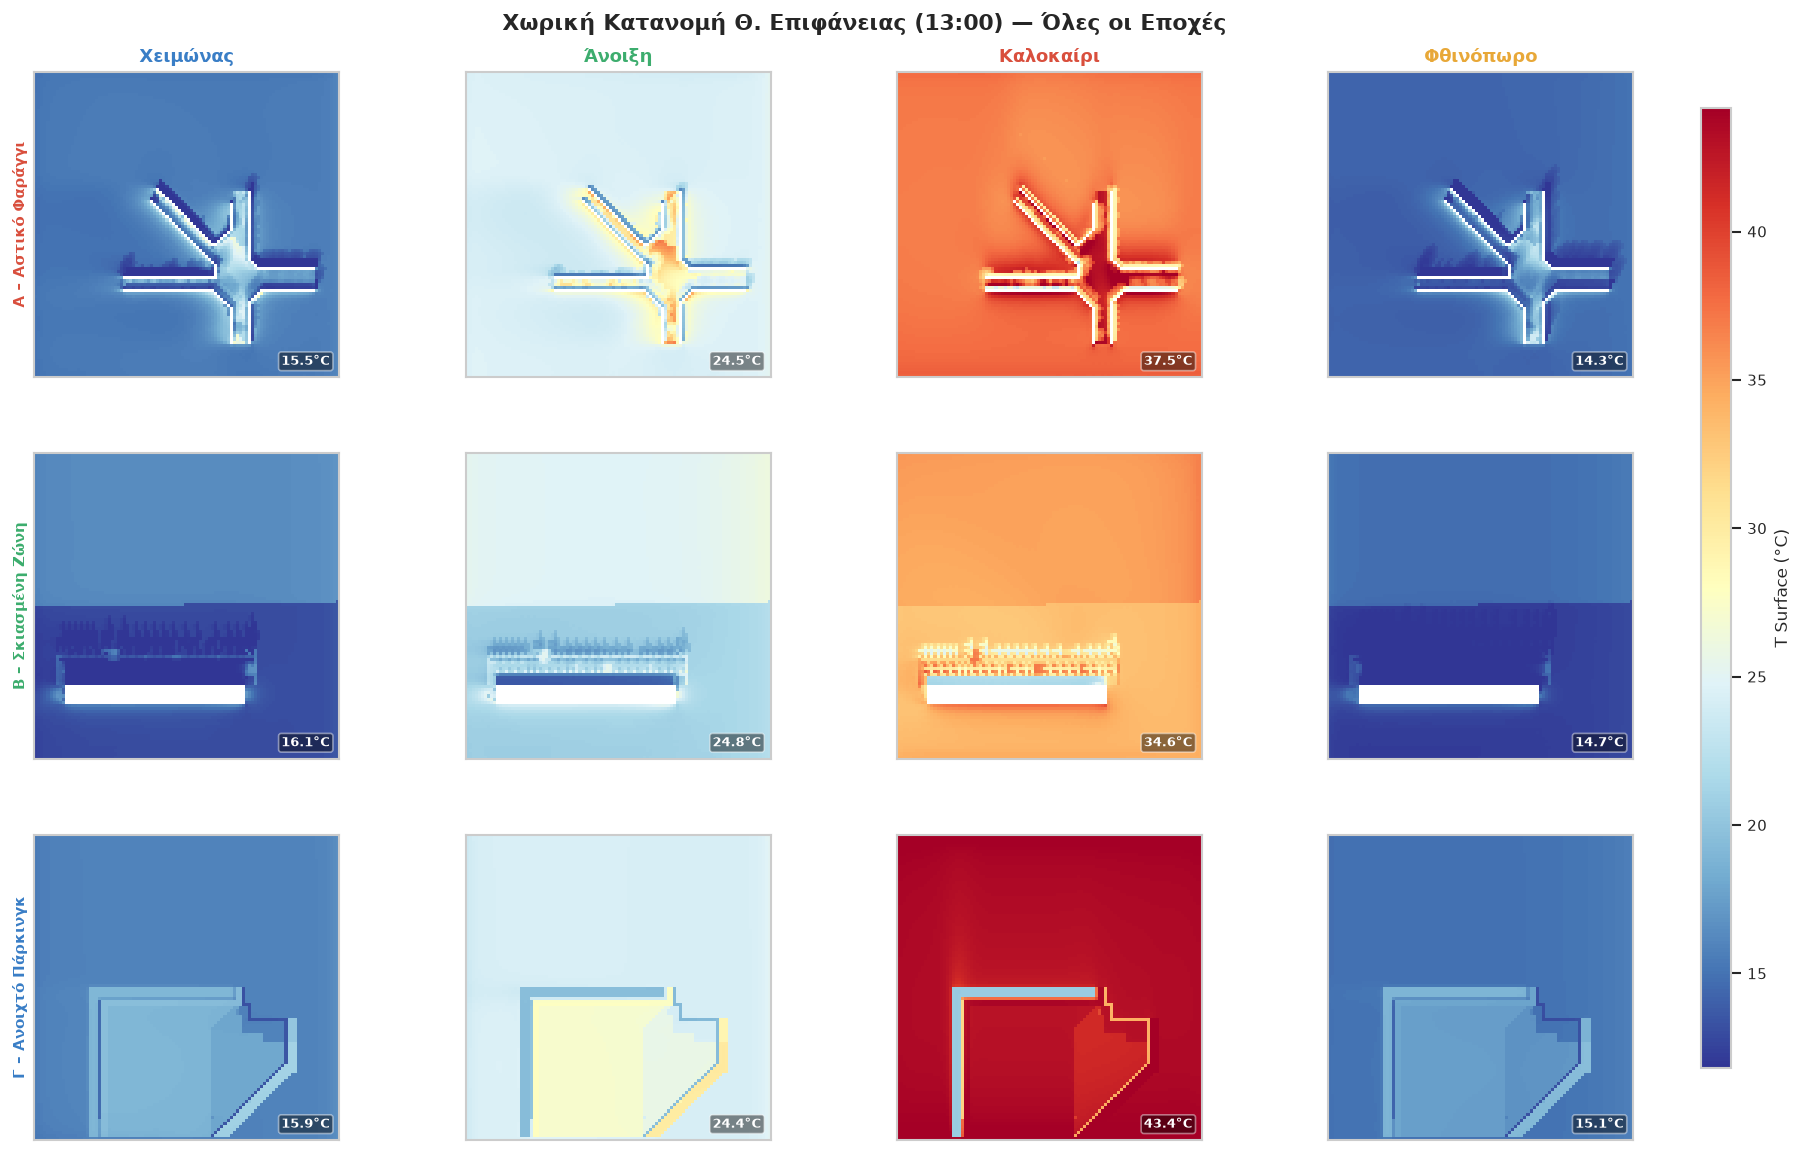

Saved G4_surface_spatial_allseasons.png  (scale: 11.8°C – 44.2°C)


In [9]:
spatial_grid(srf, SURF_TEMP_COL, hour=13,
             title='Χωρική Κατανομή Θ. Επιφάνειας (13:00) — Όλες οι Εποχές',
             fname='G4_surface_spatial_allseasons.png')


## G5 — ΔT map: cooling relative to open parking (summer, 14:00)
Shows how many degrees each cell is **cooler than the mean of Area C** (open parking).  
Directly visualises the spatial cooling benefit of vegetation and building shade.

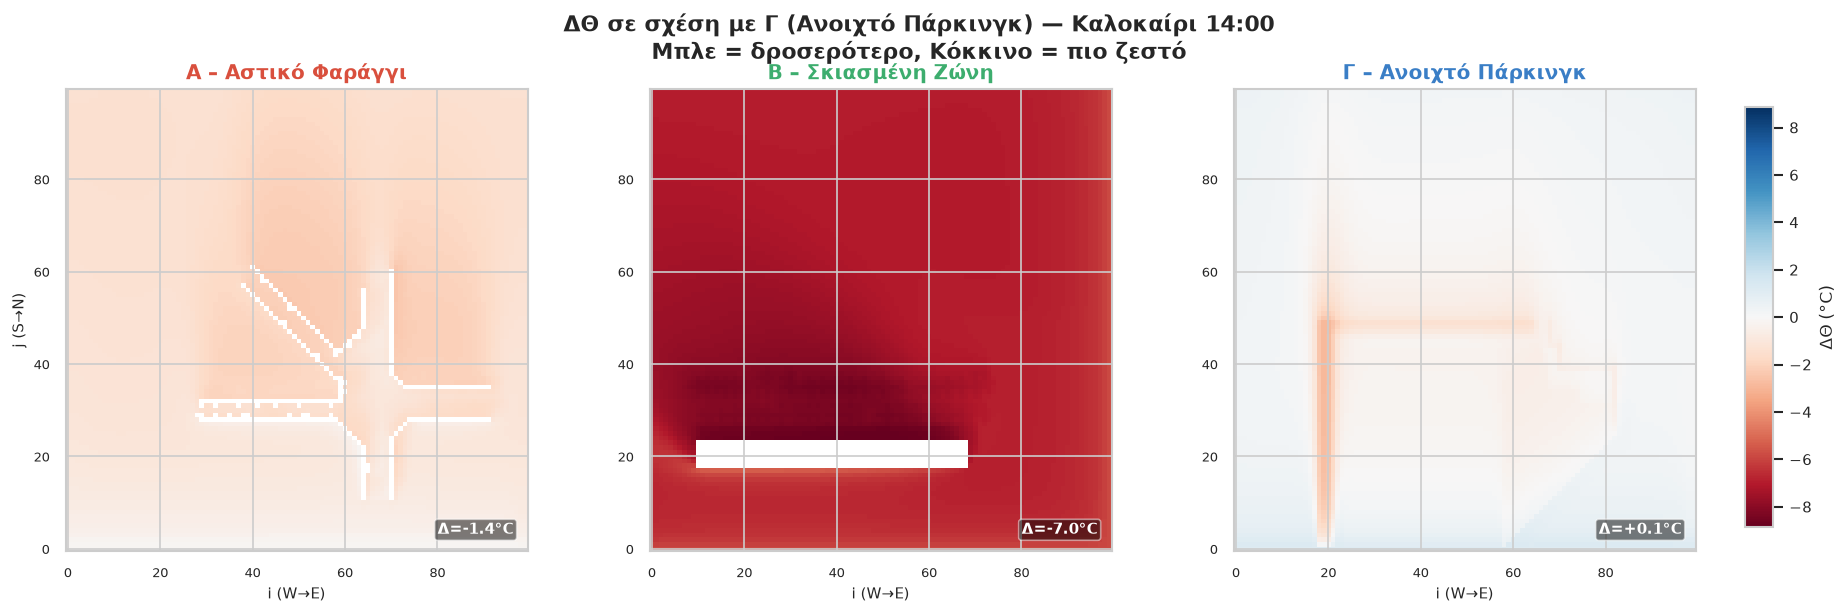

Saved G5_air_delta_vs_parking_summer.png


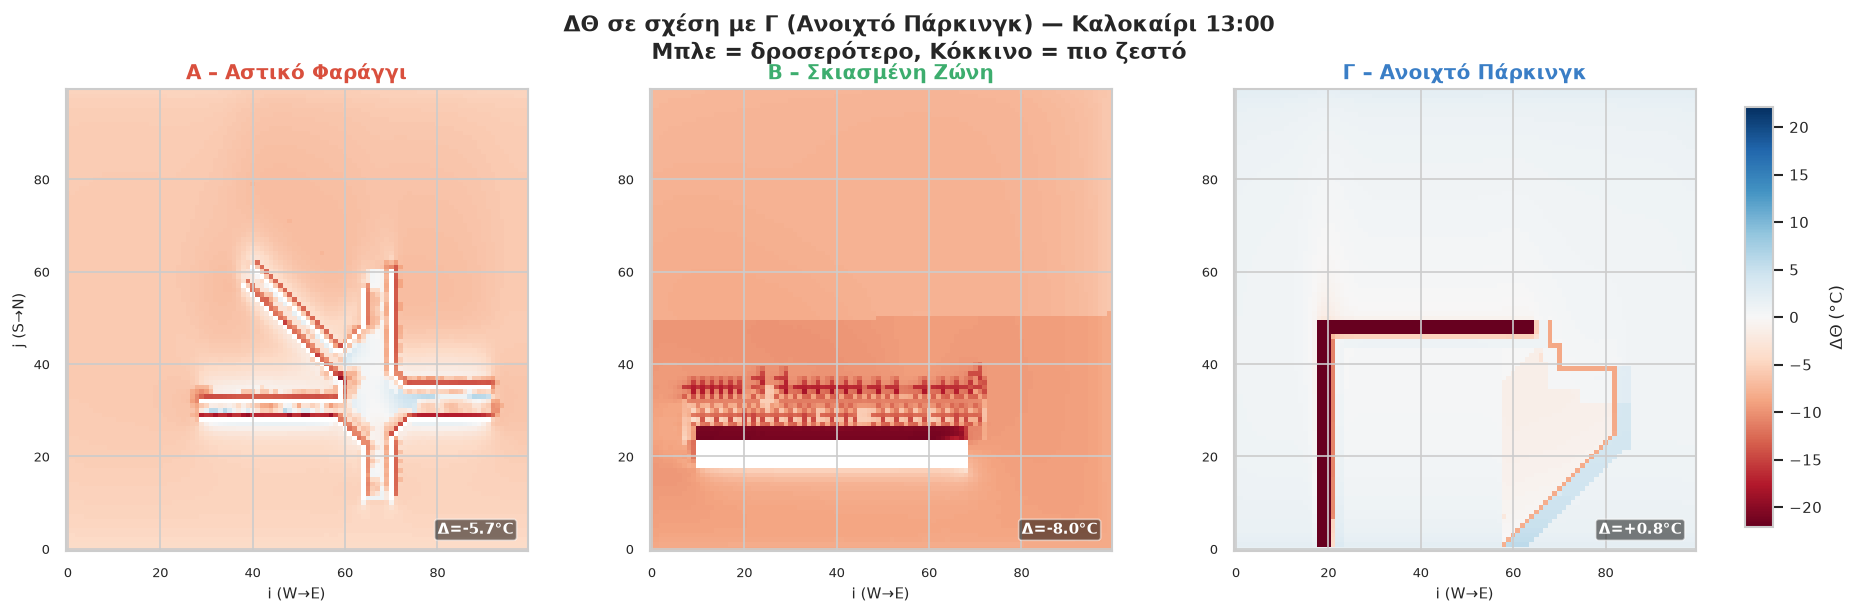

Saved G6_surface_delta_vs_parking_summer.png


In [7]:
def delta_map(df, col, hour, date, reference_area='Waterfront', fname='G5_delta_map.png'):
    """ΔT = cell_value - mean(reference_area). Blue = cooler than reference."""
    # Reference: mean temperature of the reference area at this hour/date
    ref_mean = df[
        (df['area'] == reference_area) & (df['date'] == date) & (df['hour'] == hour)
    ][col].mean()

    compare = [a for a in AREA_ORDER if a != reference_area]
    fig, axes = plt.subplots(1, len(AREA_ORDER), figsize=(16, 5))
    fig.subplots_adjust(left=0.04, right=0.92, top=0.85, bottom=0.08, wspace=0.12)
    fig.suptitle(
        f'ΔΘ σε σχέση με Γ (Ανοιχτό Πάρκινγκ) — Καλοκαίρι {hour:02d}:00\n'
        'Μπλε = δροσερότερο, Κόκκινο = πιο ζεστό',
        fontsize=13, fontweight='bold'
    )

    abs_max = 0
    grids = {}
    for area in AREA_ORDER:
        sub = df[(df['area'] == area) & (df['date'] == date) & (df['hour'] == hour)].copy()
        sub['delta'] = sub[col] - ref_mean
        grid = sub.pivot_table(index='j', columns='i', values='delta', aggfunc='mean')
        grids[area] = grid
        m = np.nanmax(np.abs(grid.values))
        if m > abs_max: abs_max = m

    im = None
    for ax, area in zip(axes, AREA_ORDER):
        grid = grids.get(area)
        if grid is None or grid.empty:
            ax.text(0.5, 0.5, '—', ha='center', va='center', transform=ax.transAxes)
            continue
        im = ax.imshow(grid.values, origin='lower', cmap='RdBu',
                       vmin=-abs_max, vmax=abs_max,
                       aspect='equal', interpolation='nearest')
        ax.set_title(GR_AREA[area], fontsize=12, fontweight='bold',
                     color=AREA_COLORS[area])
        ax.set_xlabel('i (W→E)', fontsize=9)
        ax.set_ylabel('j (S→N)' if area == AREA_ORDER[0] else '', fontsize=9)
        ax.tick_params(labelsize=8)

        med_delta = np.nanmedian(grid.values)
        ax.text(0.97, 0.03, f'Δ={med_delta:+.1f}°C', transform=ax.transAxes,
                ha='right', va='bottom', fontsize=9, fontweight='bold',
                color='white', bbox=dict(boxstyle='round,pad=0.2', fc='black', alpha=0.5))

    if im is not None:
        cbar_ax = fig.add_axes([0.93, 0.12, 0.015, 0.70])
        cb = fig.colorbar(im, cax=cbar_ax)
        cb.set_label('ΔΘ (°C)', fontsize=10)
        cb.ax.tick_params(labelsize=9)

    fig.savefig(SAVE_DIR / fname, dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved', fname)


delta_map(atm, AIR_TEMP_COL, hour=14, date='15Aug',
          fname='G5_air_delta_vs_parking_summer.png')

delta_map(srf, SURF_TEMP_COL, hour=13, date='15Aug',
          fname='G6_surface_delta_vs_parking_summer.png')

## G7 — Albedo spatial map (summer, all areas)
Higher albedo = more reflective surface = cooler.  
Shows how material choices vary spatially within each area.

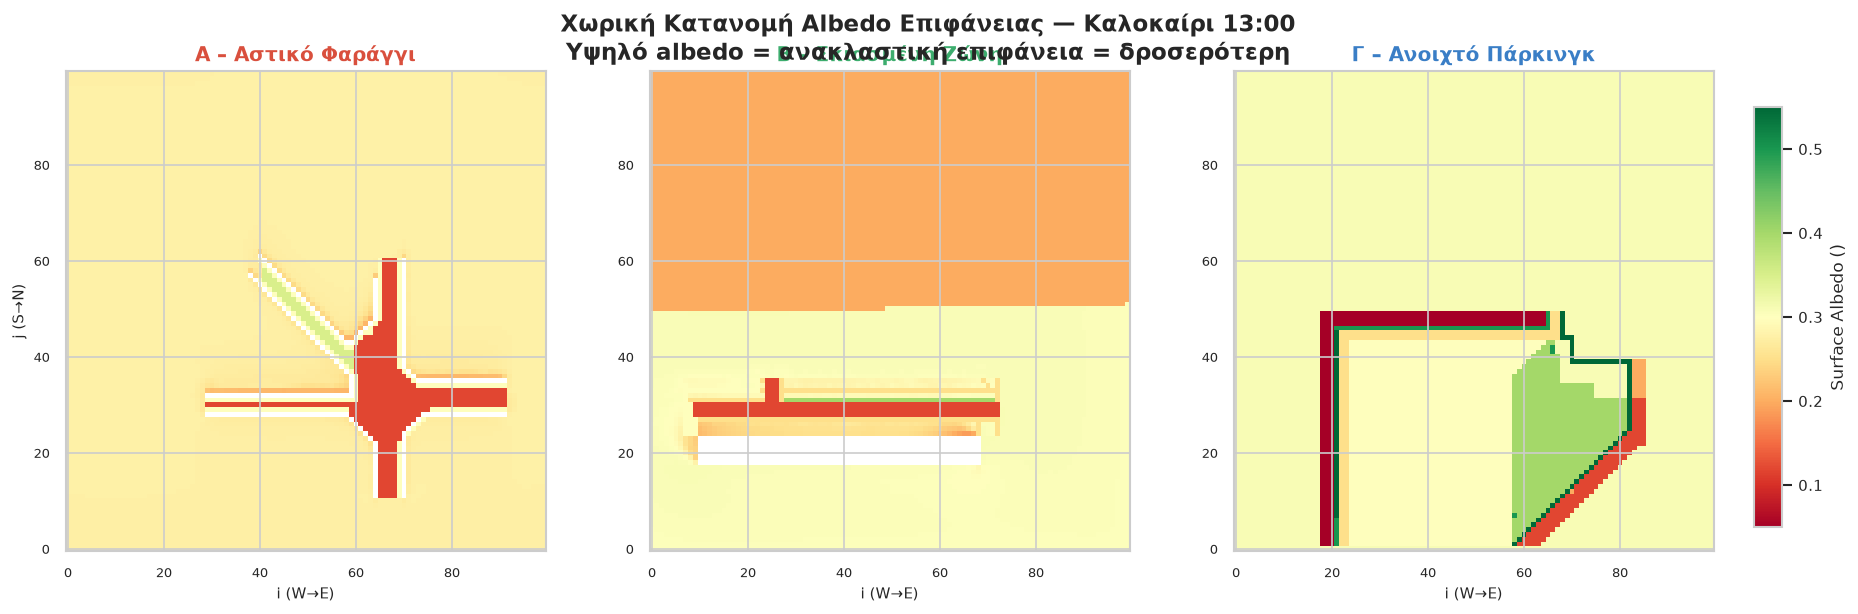

Saved G7_albedo_spatial_summer.png


In [10]:
SHADOW_COL = 'Shadow Flag ()'
SVF_COL    = 'Sky-View-Faktor ()'

# G7: Albedo spatial map — global scale, summer, hour=13 (peak surface hour)
# Albedo is a material property — does not depend on hour for most cells,
# but use 13h so it matches surface temp comparisons
spatial_map(srf, SURF_ALB_COL, hour=13, date='15Aug',
            title='Χωρική Κατανομή Albedo Επιφάνειας — Καλοκαίρι 13:00\n'
                  'Υψηλό albedo = ανακλαστική επιφάνεια = δροσερότερη',
            fname='G7_albedo_spatial_summer.png',
            cmap='RdYlGn',   # green=high albedo (vegetation/light), red=low (dark asphalt)
            vmin=0.05, vmax=0.55)


## G8 — Albedo across all seasons
Vegetation albedo changes with season (summer leaves vs winter bare branches).  
Useful to show that Area B's high summer albedo is a seasonal effect.

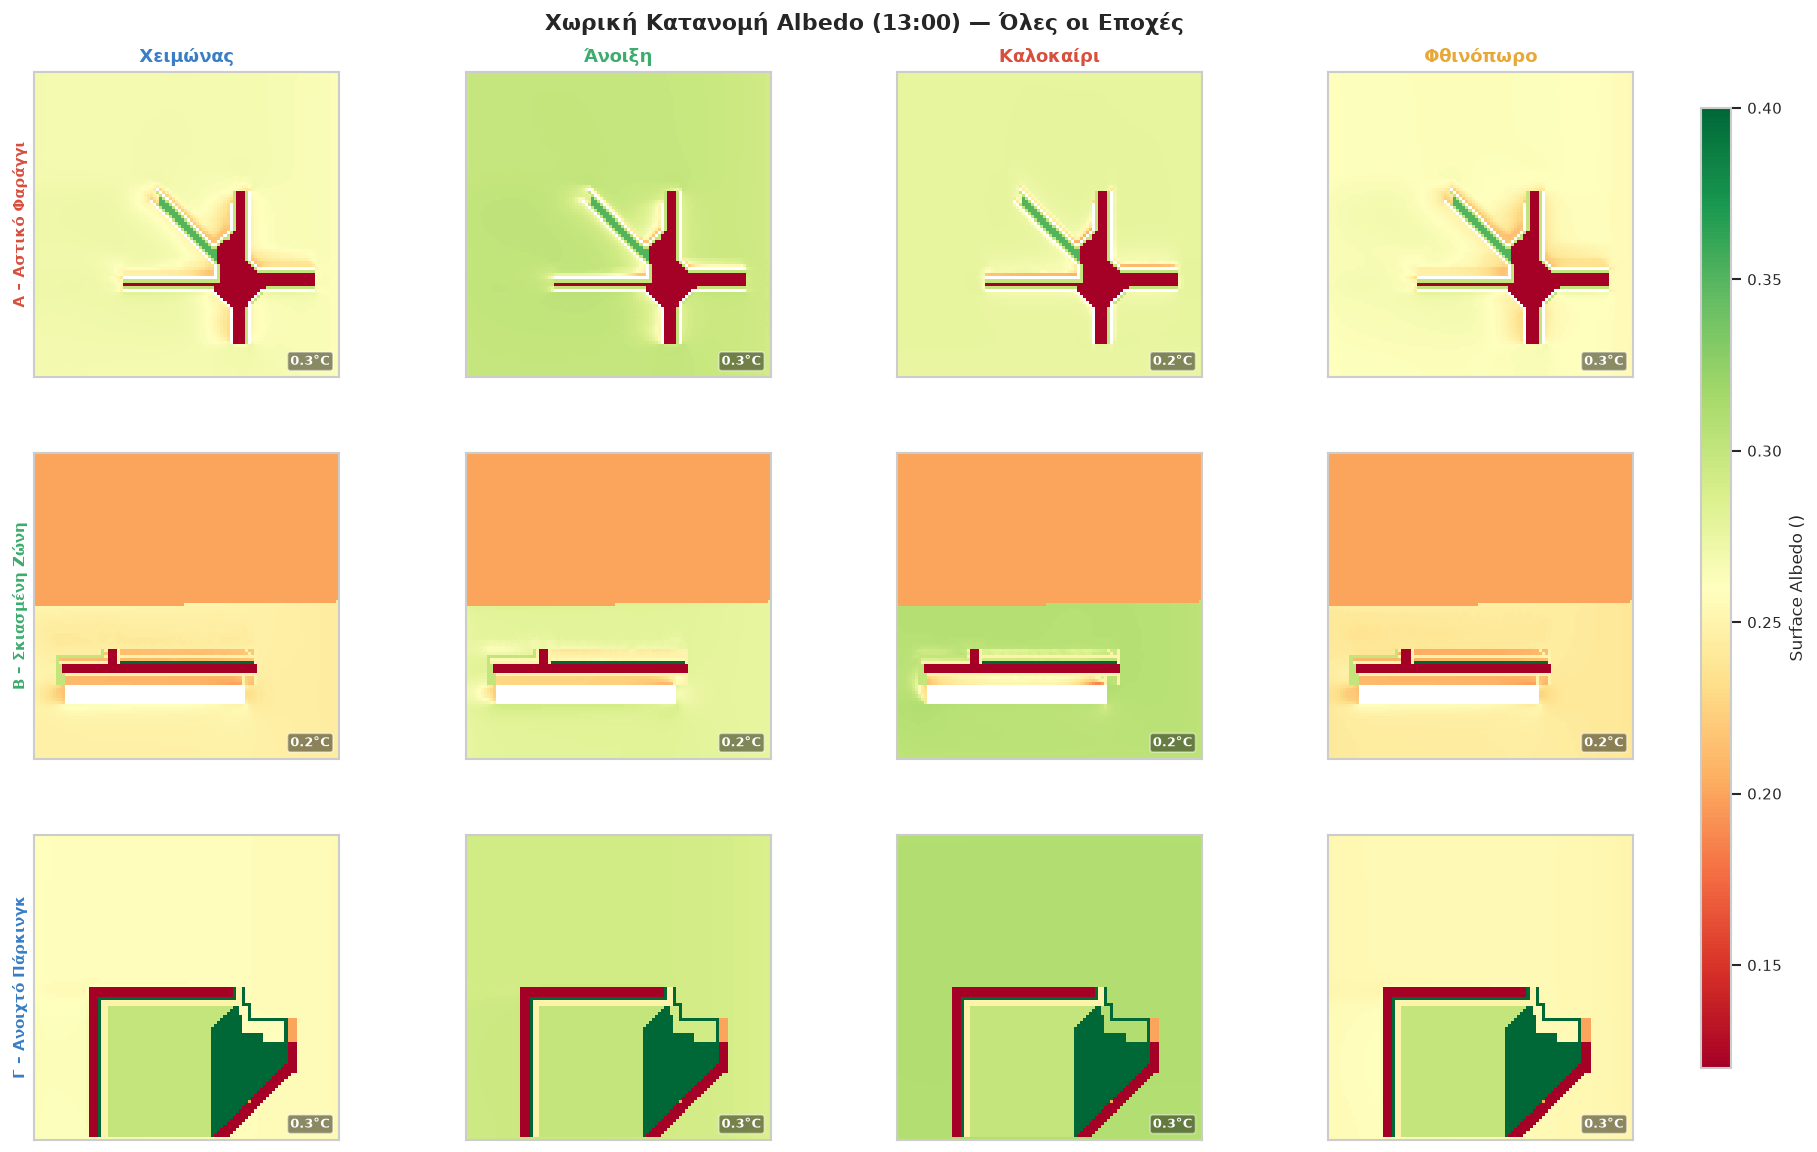

Saved G8_albedo_allseasons.png  (scale: 0.1°C – 0.4°C)


In [11]:
spatial_grid(srf, SURF_ALB_COL, hour=13,
             title='Χωρική Κατανομή Albedo (13:00) — Όλες οι Εποχές',
             fname='G8_albedo_allseasons.png',
             cmap='RdYlGn')


## G9 — Shadow flag map (summer, 13:00)
Binary: dark = cell in shadow, white = cell in full sun.  
Directly shows WHERE shade falls and explains local surface temperature patterns.

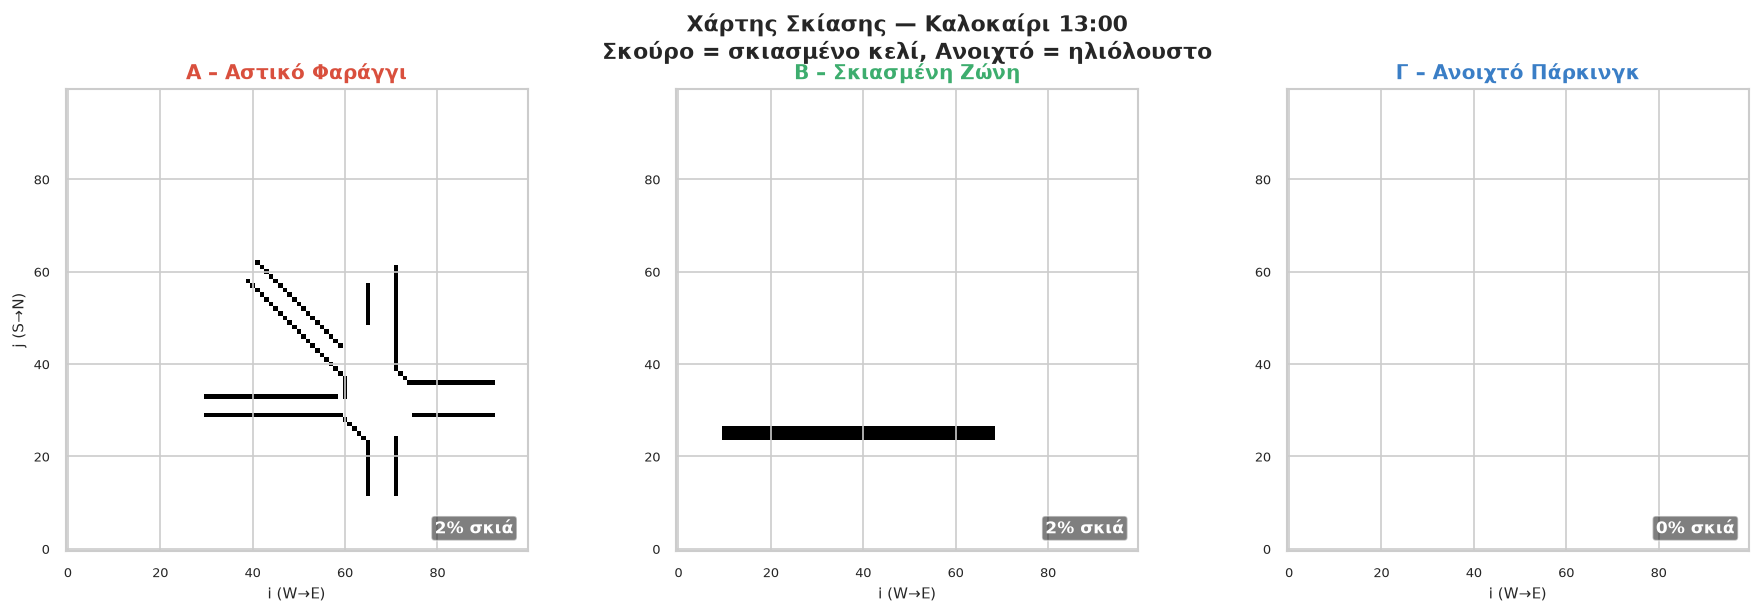

Saved G9


In [12]:
if SHADOW_COL in srf.columns:
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    fig.subplots_adjust(left=0.04, right=0.96, top=0.85, bottom=0.08, wspace=0.12)
    fig.suptitle('Χάρτης Σκίασης — Καλοκαίρι 13:00\n'
                 'Σκούρο = σκιασμένο κελί, Ανοιχτό = ηλιόλουστο',
                 fontsize=13, fontweight='bold')

    for ax, area in zip(axes, AREA_ORDER):
        sub = srf[(srf['area'] == area) & (srf['date'] == '15Aug') & (srf['hour'] == 13)]
        if len(sub) == 0:
            ax.text(0.5, 0.5, '—', ha='center', va='center', transform=ax.transAxes)
            continue
        grid = sub.pivot_table(index='j', columns='i', values=SHADOW_COL, aggfunc='mean')
        ax.imshow(grid.values, origin='lower', cmap='binary',
                  vmin=0, vmax=1, aspect='equal', interpolation='nearest')
        ax.set_title(GR_AREA[area], fontsize=12, fontweight='bold',
                     color=AREA_COLORS[area])
        ax.set_xlabel('i (W→E)', fontsize=9)
        ax.set_ylabel('j (S→N)' if area == AREA_ORDER[0] else '', fontsize=9)
        ax.tick_params(labelsize=8)

        pct_shaded = grid.values[~np.isnan(grid.values)].mean() * 100
        ax.text(0.97, 0.03, f'{pct_shaded:.0f}% σκιά', transform=ax.transAxes,
                ha='right', va='bottom', fontsize=10, fontweight='bold',
                color='white', bbox=dict(boxstyle='round,pad=0.2', fc='black', alpha=0.5))

    fig.savefig(SAVE_DIR / 'G9_shadow_flag_summer_13h.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved G9')
else:
    print(f'Column "{SHADOW_COL}" not found in surface data.')


## G10 — Sky-View Factor (SVF) spatial map
SVF = fraction of sky visible from each cell. Low SVF = enclosed by buildings (canyon effect).  
Explains why Area A has building shade without vegetation cooling.

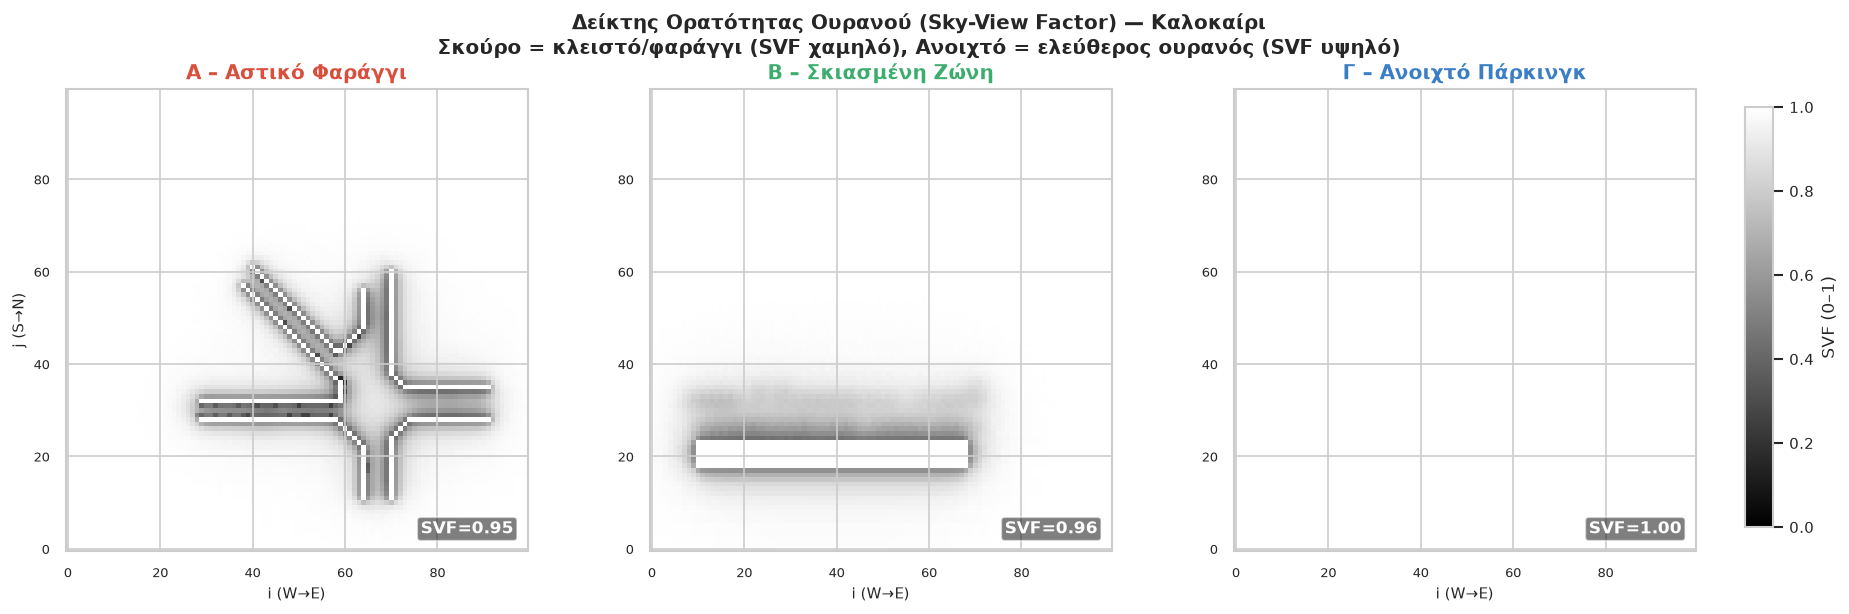

Saved G10


In [13]:
if SVF_COL in srf.columns:
    # SVF doesn't depend on hour — use any hour, summer for consistency
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    fig.subplots_adjust(left=0.04, right=0.92, top=0.85, bottom=0.08, wspace=0.12)
    fig.suptitle('Δείκτης Ορατότητας Ουρανού (Sky-View Factor) — Καλοκαίρι\n'
                 'Σκούρο = κλειστό/φαράγγι (SVF χαμηλό), Ανοιχτό = ελεύθερος ουρανός (SVF υψηλό)',
                 fontsize=12, fontweight='bold')

    im = None
    for ax, area in zip(axes, AREA_ORDER):
        sub = srf[(srf['area'] == area) & (srf['date'] == '15Aug') & (srf['hour'] == 12)]
        if len(sub) == 0:
            ax.text(0.5, 0.5, '—', ha='center', va='center', transform=ax.transAxes)
            continue
        grid = sub.pivot_table(index='j', columns='i', values=SVF_COL, aggfunc='mean')
        im = ax.imshow(grid.values, origin='lower', cmap='gray',
                       vmin=0, vmax=1, aspect='equal', interpolation='nearest')
        ax.set_title(GR_AREA[area], fontsize=12, fontweight='bold',
                     color=AREA_COLORS[area])
        ax.set_xlabel('i (W→E)', fontsize=9)
        ax.set_ylabel('j (S→N)' if area == AREA_ORDER[0] else '', fontsize=9)
        ax.tick_params(labelsize=8)

        mean_svf = grid.values[~np.isnan(grid.values)].mean()
        ax.text(0.97, 0.03, f'SVF={mean_svf:.2f}', transform=ax.transAxes,
                ha='right', va='bottom', fontsize=10, fontweight='bold',
                color='white', bbox=dict(boxstyle='round,pad=0.2', fc='black', alpha=0.5))

    if im is not None:
        cbar_ax = fig.add_axes([0.93, 0.12, 0.015, 0.70])
        cb = fig.colorbar(im, cax=cbar_ax)
        cb.set_label('SVF (0–1)', fontsize=10)
        cb.ax.tick_params(labelsize=9)

    fig.savefig(SAVE_DIR / 'G10_svf_spatial.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved G10')
else:
    print(f'Column "{SVF_COL}" not found.')


## G11 — Albedo vs Surface Temperature scatter (summer, 13:00)
Per-cell scatter: does higher albedo directly translate to lower surface temperature?  
Shows the design lever: cool materials (high albedo) reduce surface heat independently of shade.

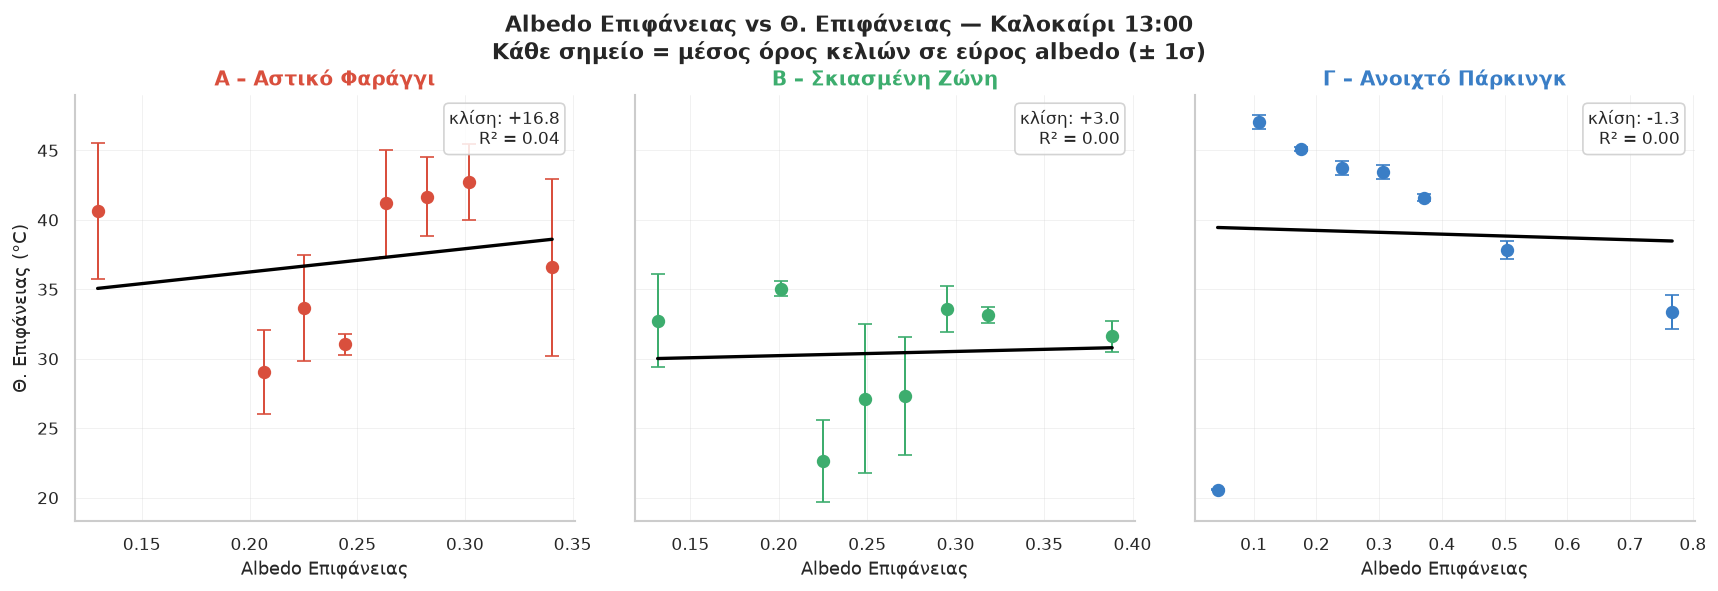

Saved G11


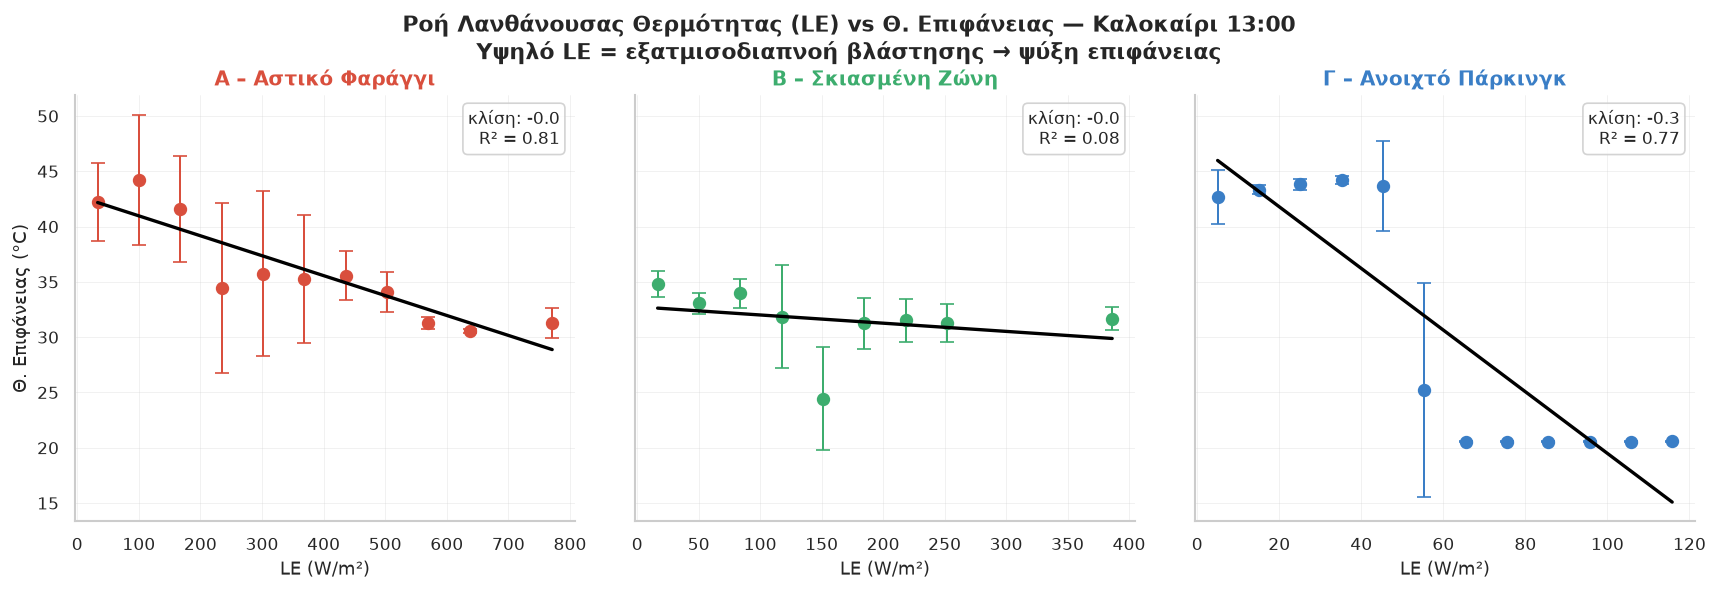

Saved G12


In [15]:
from scipy import stats as scipy_stats

LE_COL  = 'Latent Heat Flux LE (W/m2)'   # evapotranspiration proxy
SW_COL  = 'Direct SW Radiation Horizontal (W/m2)'

GR_AREA_SHORT = {
    'Zefkseidos': 'Α – Αστικό Φαράγγι',
    'Shaded':     'Β – Σκιασμένη Ζώνη',
    'Waterfront': 'Γ – Ανοιχτό Πάρκινγκ',
}

def binned_scatter(ax, x, y, n_bins, clr, x_label, y_label, area):
    """Bin x into n_bins, plot mean ± 1 std of y per bin + regression on bin means."""
    bins = pd.cut(x, bins=n_bins)
    grp  = pd.DataFrame({'x': x, 'y': y}).groupby(bins, observed=True)['y']
    mn   = grp.mean()
    sd   = grp.std()
    xc   = np.array([iv.mid for iv in mn.index])          # bin centres

    # keep bins with enough data
    cnt  = grp.count()
    mask = cnt >= 5
    xc, mn, sd = xc[mask], mn[mask], sd[mask]

    ax.errorbar(xc, mn, yerr=sd, fmt='o', color=clr,
                markersize=7, capsize=4, lw=1.8, elinewidth=1.2, zorder=3)

    if len(xc) >= 2:
        slope, intercept, r, p, _ = scipy_stats.linregress(xc, mn)
        xr = np.linspace(xc.min(), xc.max(), 100)
        ax.plot(xr, slope * xr + intercept, color='black', lw=2, zorder=5)
        sign = '+' if slope >= 0 else ''
        ax.text(0.97, 0.97,
                f'κλίση: {sign}{slope:.1f}\nR² = {r**2:.2f}',
                transform=ax.transAxes, ha='right', va='top', fontsize=10,
                bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.85, ec='#ccc'))

    ax.set_xlabel(x_label, fontsize=11)
    ax.set_ylabel(y_label, fontsize=11)
    ax.set_title(GR_AREA_SHORT[area], fontsize=12, fontweight='bold', color=clr)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(lw=0.4, alpha=0.4)
    ax.tick_params(labelsize=10)


# ── Figure 1: Albedo vs Surface Temperature (binned) ─────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
fig.subplots_adjust(left=0.07, right=0.97, top=0.84, bottom=0.13, wspace=0.12)
fig.suptitle('Albedo Επιφάνειας vs Θ. Επιφάνειας — Καλοκαίρι 13:00\n'
             'Κάθε σημείο = μέσος όρος κελιών σε εύρος albedo (± 1σ)',
             fontsize=13, fontweight='bold')

for ax, area in zip(axes, AREA_ORDER):
    sub = srf[
        (srf['area'] == area) & (srf['date'] == '15Aug') & (srf['hour'] == 13)
    ][[SURF_ALB_COL, SURF_TEMP_COL]].dropna()
    if len(sub) < 20:
        ax.text(0.5, 0.5, '—', ha='center', va='center', transform=ax.transAxes)
        continue
    binned_scatter(ax, sub[SURF_ALB_COL], sub[SURF_TEMP_COL],
                   n_bins=12, clr=AREA_COLORS[area],
                   x_label='Albedo Επιφάνειας',
                   y_label='Θ. Επιφάνειας (°C)' if area == AREA_ORDER[0] else '',
                   area=area)

fig.savefig(SAVE_DIR / 'G11_albedo_vs_surftemp_binned.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved G11')


# ── Figure 2: Latent Heat Flux vs Surface Temperature (binned) ───────────────
# LE > 0 means evapotranspiration is happening → explains vegetation cooling
if LE_COL in srf.columns:
    fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
    fig.subplots_adjust(left=0.07, right=0.97, top=0.84, bottom=0.13, wspace=0.12)
    fig.suptitle('Ροή Λανθάνουσας Θερμότητας (LE) vs Θ. Επιφάνειας — Καλοκαίρι 13:00\n'
                 'Υψηλό LE = εξατμισοδιαπνοή βλάστησης → ψύξη επιφάνειας',
                 fontsize=13, fontweight='bold')

    for ax, area in zip(axes, AREA_ORDER):
        sub = srf[
            (srf['area'] == area) & (srf['date'] == '15Aug') & (srf['hour'] == 13)
        ][[LE_COL, SURF_TEMP_COL]].dropna()
        # keep physically meaningful range (LE can be slightly negative at night)
        sub = sub[sub[LE_COL] >= 0]
        if len(sub) < 20:
            ax.text(0.5, 0.5, '—', ha='center', va='center', transform=ax.transAxes)
            continue
        binned_scatter(ax, sub[LE_COL], sub[SURF_TEMP_COL],
                       n_bins=12, clr=AREA_COLORS[area],
                       x_label='LE (W/m²)',
                       y_label='Θ. Επιφάνειας (°C)' if area == AREA_ORDER[0] else '',
                       area=area)

    fig.savefig(SAVE_DIR / 'G12_LE_vs_surftemp_binned.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved G12')
else:
    print(f'Column "{LE_COL}" not found in surface data.')


## G13 — Albedo distribution by area and season (violin)
Shows that vegetation (Area B) has higher and more variable albedo than uniform pavements.
The seasonal change in B reveals that leaf cover drives the effect — not just material choice.

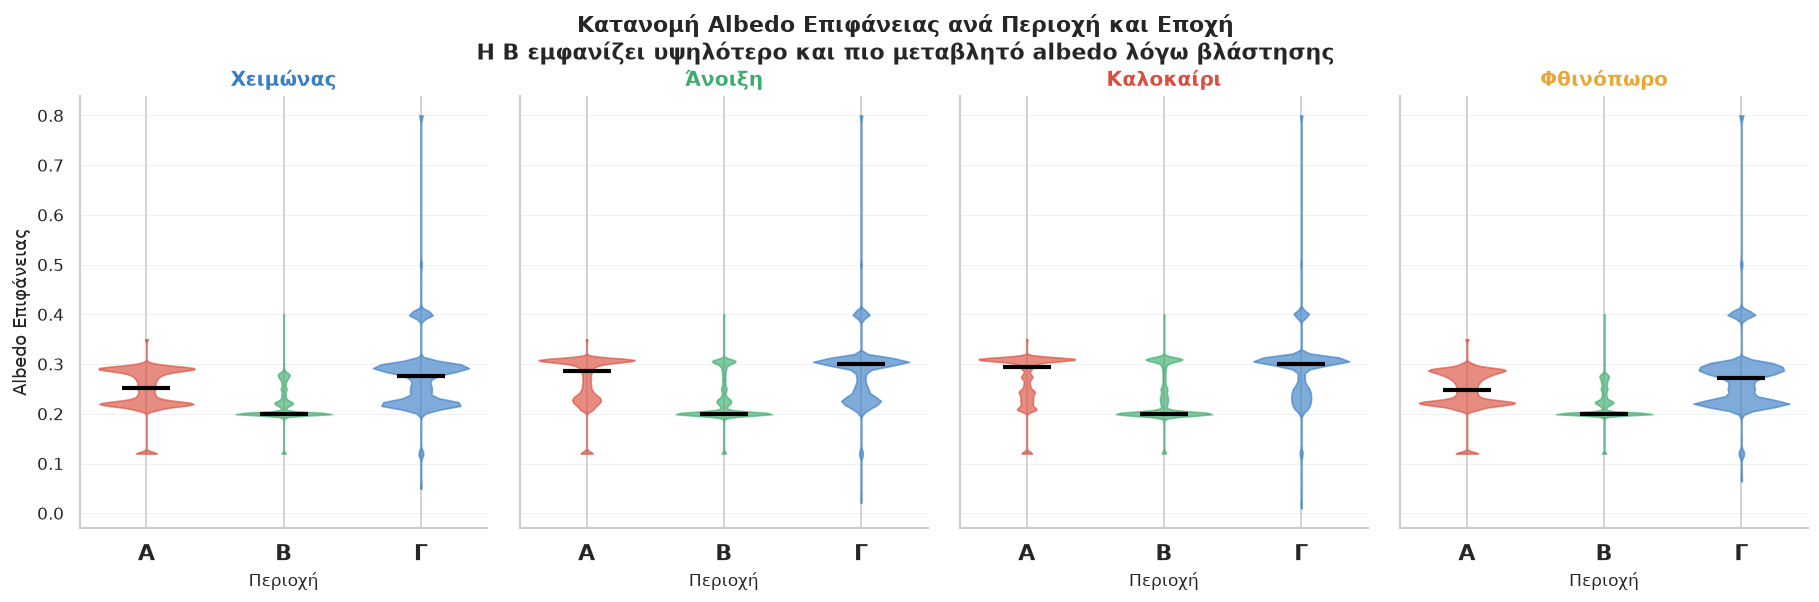

Saved G13


In [16]:
GR_DATE = {'15Feb': 'Χειμώνας', '31Mar': 'Άνοιξη', '15Aug': 'Καλοκαίρι', '15Nov': 'Φθινόπωρο'}
GR_AREA_S = {
    'Zefkseidos': 'Α',
    'Shaded':     'Β',
    'Waterfront': 'Γ',
}

# ── G13: Violin of albedo per area × season ───────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(16, 5), sharey=True)
fig.subplots_adjust(left=0.07, right=0.97, top=0.84, bottom=0.12, wspace=0.08)
fig.suptitle('Κατανομή Albedo Επιφάνειας ανά Περιοχή και Εποχή\n'
             'Η Β εμφανίζει υψηλότερο και πιο μεταβλητό albedo λόγω βλάστησης',
             fontsize=13, fontweight='bold')

for ax, date in zip(axes, DATE_ORDER):
    data   = []
    labels = []
    colors = []
    for area in AREA_ORDER:
        sub = srf[(srf['area'] == area) & (srf['date'] == date)][SURF_ALB_COL].dropna()
        if len(sub) == 0: continue
        data.append(sub.values)
        labels.append(GR_AREA_S[area])
        colors.append(AREA_COLORS[area])

    parts = ax.violinplot(data, positions=range(len(data)),
                          showmedians=True, showextrema=False, widths=0.7)

    for body, clr in zip(parts['bodies'], colors):
        body.set_facecolor(clr)
        body.set_alpha(0.65)
        body.set_edgecolor(clr)
    parts['cmedians'].set_color('black')
    parts['cmedians'].set_linewidth(2.5)

    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, fontsize=13, fontweight='bold')
    ax.set_title(GR_DATE[date], fontsize=12, fontweight='bold',
                 color=DATE_COLORS[date])
    ax.set_xlabel('Περιοχή', fontsize=10)
    if date == DATE_ORDER[0]:
        ax.set_ylabel('Albedo Επιφάνειας', fontsize=11)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y', lw=0.4, alpha=0.4)
    ax.tick_params(axis='y', labelsize=10)

fig.savefig(SAVE_DIR / 'G13_albedo_violin_by_season.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved G13')


## G14 — Sunlit cells only: clean albedo → temperature relationship
Filtering to `Shadow Flag = 0` removes the shade confound.  
Now the albedo effect is isolated: same sun exposure, different material reflectivity.

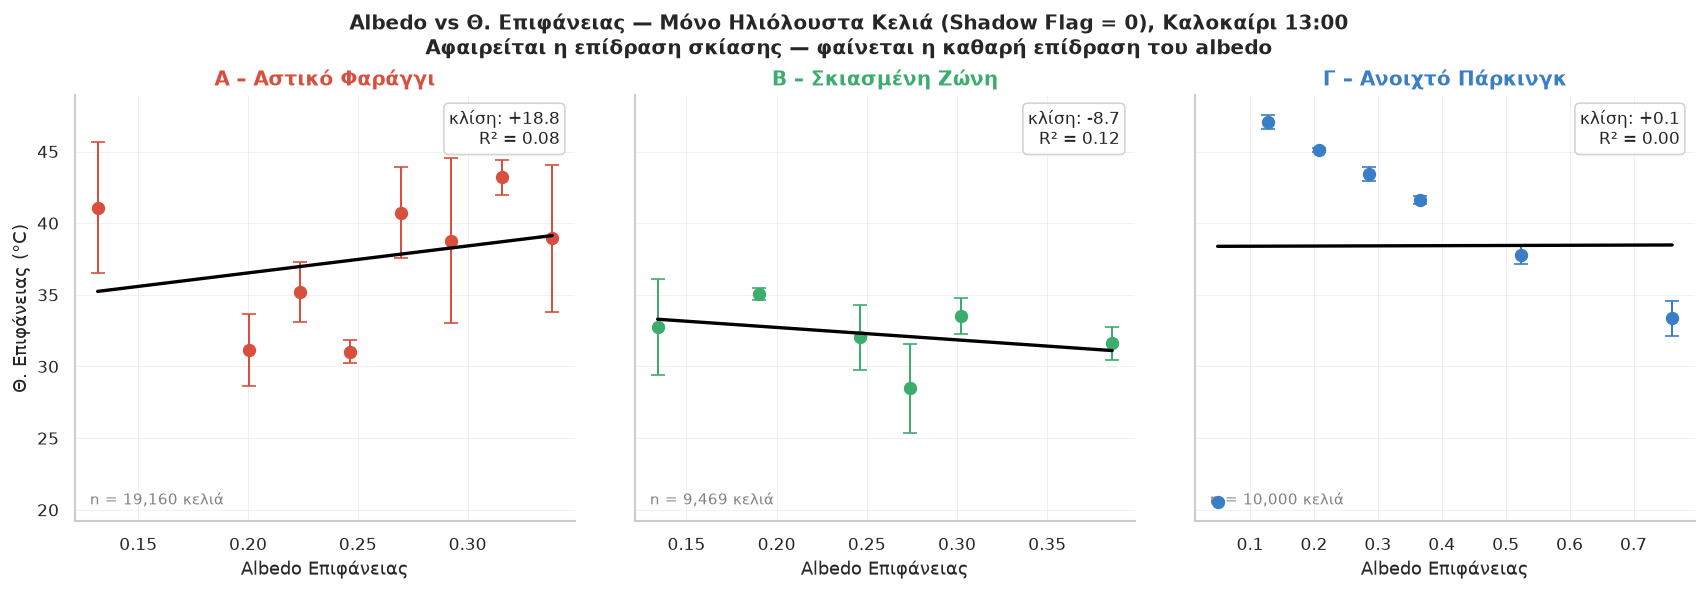

Saved G14


In [17]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
fig.subplots_adjust(left=0.07, right=0.97, top=0.84, bottom=0.13, wspace=0.12)
fig.suptitle('Albedo vs Θ. Επιφάνειας — Μόνο Ηλιόλουστα Κελιά (Shadow Flag = 0), Καλοκαίρι 13:00\n'
             'Αφαιρείται η επίδραση σκίασης — φαίνεται η καθαρή επίδραση του albedo',
             fontsize=12, fontweight='bold')

for ax, area in zip(axes, AREA_ORDER):
    sub = srf[
        (srf['area'] == area) & (srf['date'] == '15Aug') & (srf['hour'] == 13) &
        (srf[SHADOW_COL] == 0)
    ][[SURF_ALB_COL, SURF_TEMP_COL]].dropna()

    if len(sub) < 20:
        ax.text(0.5, 0.5, f'Πολύ λίγα\nηλιόλουστα\nκελιά\n(n={len(sub)})',
                ha='center', va='center', transform=ax.transAxes,
                color='grey', fontsize=11)
        ax.set_title(GR_AREA_SHORT[area], fontsize=12, fontweight='bold',
                     color=AREA_COLORS[area])
        continue

    binned_scatter(ax, sub[SURF_ALB_COL], sub[SURF_TEMP_COL],
                   n_bins=10, clr=AREA_COLORS[area],
                   x_label='Albedo Επιφάνειας',
                   y_label='Θ. Επιφάνειας (°C)' if area == AREA_ORDER[0] else '',
                   area=area)
    ax.text(0.03, 0.04, f'n = {len(sub):,} κελιά',
            transform=ax.transAxes, fontsize=9, color='grey')

fig.savefig(SAVE_DIR / 'G14_albedo_sunlit_only.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved G14')


## G15 — Cool materials counterfactual: policy recommendation
Using the sunlit-cell regression slope, estimates how much surface temperature would drop  
if Area C (open parking, low albedo asphalt) adopted cool pavement materials.  
**This is the thesis conclusion: a concrete, quantified design intervention.**


Σύνοψη — Δυνητική μείωση θερμοκρασίας (ηλιόλουστα κελιά, Αύγουστος 13:00):
Περιοχή                          Τρέχον albedo   Τρέχουσα Θ (°C)  Θ σε alb={TARGET_ALBEDO}    ΔΘ (°C)      R²
Α – Αστικό Φαράγγι                       0.246              40.0              42.2       +2.2   0.076
Β – Σκιασμένη Ζώνη                       0.200              34.7              30.1       -4.5   0.119
Γ – Ανοιχτό Πάρκινγκ                     0.310              43.4              38.4       -5.0   0.000


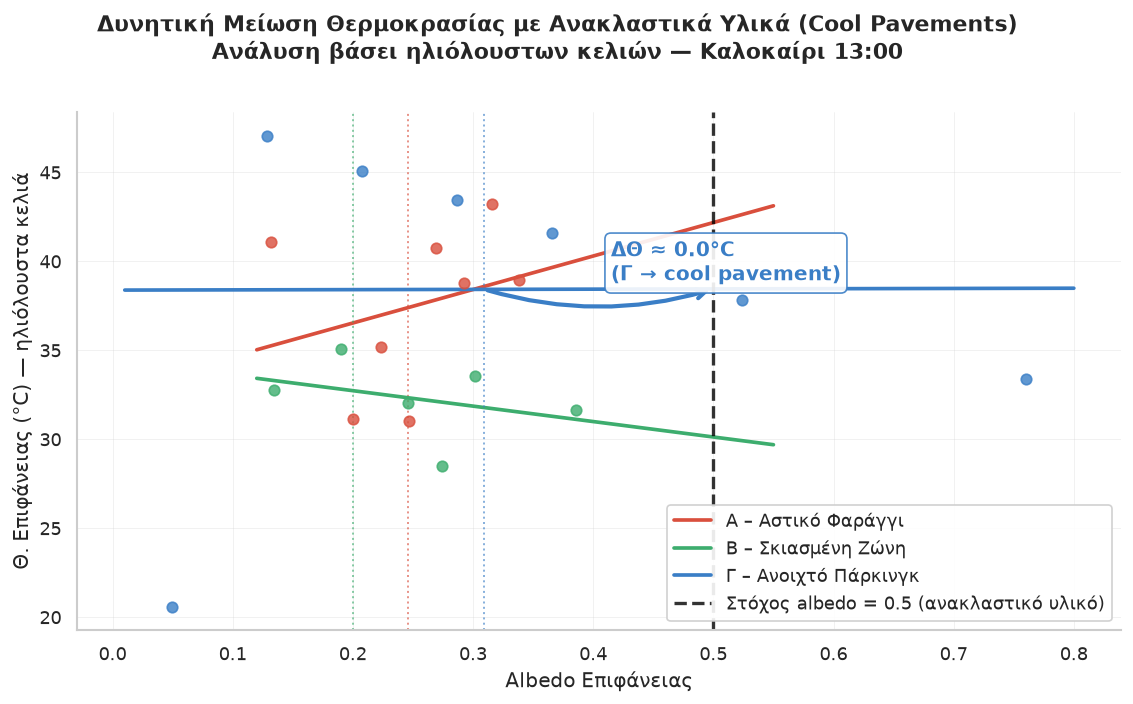


Saved G15


In [18]:
TARGET_ALBEDO = 0.50   # typical cool pavement / light-coloured concrete

fig, ax = plt.subplots(figsize=(10, 6))
fig.subplots_adjust(left=0.10, right=0.97, top=0.84, bottom=0.12)
fig.suptitle('Δυνητική Μείωση Θερμοκρασίας με Ανακλαστικά Υλικά (Cool Pavements)\n'
             'Ανάλυση βάσει ηλιόλουστων κελιών — Καλοκαίρι 13:00',
             fontsize=13, fontweight='bold')

results = {}
for area in AREA_ORDER:
    sub = srf[
        (srf['area'] == area) & (srf['date'] == '15Aug') & (srf['hour'] == 13) &
        (srf[SHADOW_COL] == 0)
    ][[SURF_ALB_COL, SURF_TEMP_COL]].dropna()
    if len(sub) < 20:
        continue

    # Binned means for clean regression
    bins = pd.cut(sub[SURF_ALB_COL], bins=10)
    grp  = sub.groupby(bins, observed=True)
    xc   = np.array([iv.mid for iv in grp[SURF_ALB_COL].mean().index])
    yn   = grp[SURF_TEMP_COL].mean().values
    cnt  = grp[SURF_TEMP_COL].count().values
    mask = cnt >= 5
    xc, yn = xc[mask], yn[mask]
    if len(xc) < 2:
        continue

    slope, intercept, r, _, _ = scipy_stats.linregress(xc, yn)
    results[area] = {'slope': slope, 'intercept': intercept,
                     'r2': r**2,
                     'current_alb': sub[SURF_ALB_COL].median(),
                     'current_T':   sub[SURF_TEMP_COL].median()}

    clr = AREA_COLORS[area]
    xr  = np.linspace(sub[SURF_ALB_COL].quantile(0.01),
                      max(sub[SURF_ALB_COL].quantile(0.99), TARGET_ALBEDO + 0.05), 200)
    ax.plot(xr, slope * xr + intercept, color=clr, lw=2.2, label=GR_AREA_SHORT[area])

    # Scatter of bin means
    ax.scatter(xc, yn, color=clr, s=40, zorder=4, alpha=0.8)

    # Current albedo marker
    cur_alb = results[area]['current_alb']
    cur_T   = slope * cur_alb + intercept
    ax.axvline(cur_alb, color=clr, lw=1.2, ls=':', alpha=0.6)

# Target albedo line
ax.axvline(TARGET_ALBEDO, color='black', lw=2, ls='--', alpha=0.8,
           label=f'Στόχος albedo = {TARGET_ALBEDO} (ανακλαστικό υλικό)')

# Annotate Area C counterfactual
if 'Waterfront' in results:
    r = results['Waterfront']
    cur_alb = r['current_alb']
    cur_T   = r['slope'] * cur_alb   + r['intercept']
    tgt_T   = r['slope'] * TARGET_ALBEDO + r['intercept']
    delta_T = tgt_T - cur_T

    clr = AREA_COLORS['Waterfront']
    ax.annotate('', xy=(TARGET_ALBEDO, tgt_T), xytext=(cur_alb, cur_T),
                arrowprops=dict(arrowstyle='->', color=clr, lw=2.5,
                                connectionstyle='arc3,rad=0.15'))
    ax.text((cur_alb + TARGET_ALBEDO) / 2 + 0.01,
            (cur_T + tgt_T) / 2 + 0.5,
            f'ΔΘ ≈ {delta_T:.1f}°C\n(Γ → cool pavement)',
            color=clr, fontsize=12, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.9, ec=clr))

ax.set_xlabel('Albedo Επιφάνειας', fontsize=12)
ax.set_ylabel('Θ. Επιφάνειας (°C) — ηλιόλουστα κελιά', fontsize=12)
ax.legend(fontsize=11, frameon=True, framealpha=0.9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(lw=0.4, alpha=0.4)
ax.tick_params(labelsize=11)

# Summary table below plot
print('\nΣύνοψη — Δυνητική μείωση θερμοκρασίας (ηλιόλουστα κελιά, Αύγουστος 13:00):')
print(f'{"Περιοχή":30s}  {"Τρέχον albedo":>14}  {"Τρέχουσα Θ (°C)":>16}  '
      f'{"Θ σε alb={TARGET_ALBEDO}":>16}  {"ΔΘ (°C)":>9}  {"R²":>6}')
for area, r in results.items():
    tgt_T   = r['slope'] * TARGET_ALBEDO + r['intercept']
    delta_T = tgt_T - r['current_T']
    print(f'{GR_AREA_SHORT[area]:30s}  {r["current_alb"]:>14.3f}  '
          f'{r["current_T"]:>16.1f}  {tgt_T:>16.1f}  {delta_T:>+9.1f}  {r["r2"]:>6.3f}')

fig.savefig(SAVE_DIR / 'G15_cool_materials_counterfactual.png', dpi=150, bbox_inches='tight')
plt.show()
print('\nSaved G15')


## G16 — Causal chain spatial map: Albedo → Shadow → Surface Temperature
Same cells, same hour. Reading top→bottom shows the mechanism:  
material reflectivity + shade geometry = resulting surface temperature.

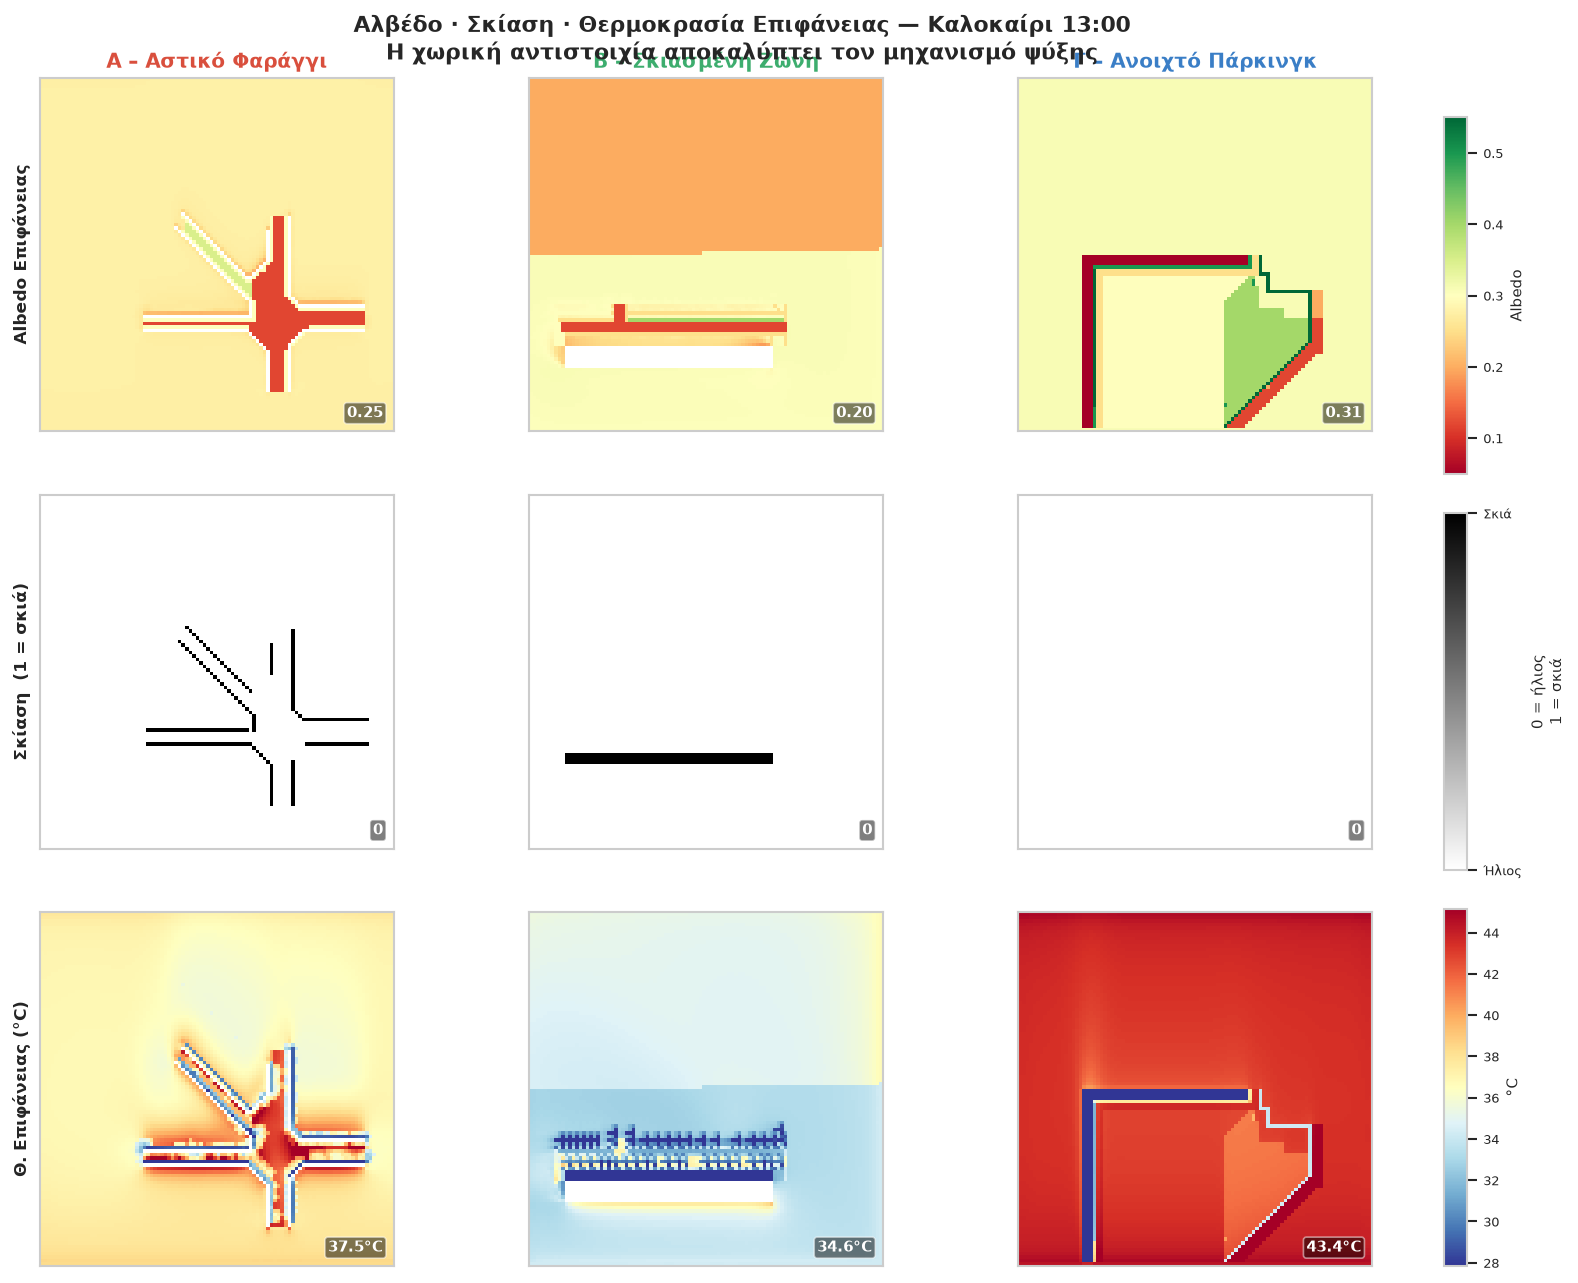

Saved G16


In [19]:
DATE   = '15Aug'
HOUR   = 13
ROWS   = [
    # (column in srf,  colormap,    global vmin, global vmax, row label,           cbar label)
    (SURF_ALB_COL,  'RdYlGn',    0.05,  0.55,  'Albedo Επιφάνειας',          'Albedo'),
    (SHADOW_COL,    'binary',    0.0,   1.0,   'Σκίαση  (1 = σκιά)',         '0 = ήλιος\n1 = σκιά'),
    (SURF_TEMP_COL, 'RdYlBu_r',  None,  None,  'Θ. Επιφάνειας (°C)',         '°C'),
]

# Compute global T limits from data
t_vals = srf[(srf['date'] == DATE) & (srf['hour'] == HOUR)][SURF_TEMP_COL].dropna()
ROWS[2] = (SURF_TEMP_COL, 'RdYlBu_r',
           t_vals.quantile(0.02), t_vals.quantile(0.98),
           'Θ. Επιφάνειας (°C)', '°C')

n_rows = len(ROWS)
n_cols = len(AREA_ORDER)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 11))
fig.subplots_adjust(left=0.08, right=0.88, top=0.93, bottom=0.03,
                    wspace=0.06, hspace=0.18)
fig.suptitle(
    f'Αλβέδο · Σκίαση · Θερμοκρασία Επιφάνειας — Καλοκαίρι {HOUR:02d}:00\n'
    'Η χωρική αντιστοιχία αποκαλύπτει τον μηχανισμό ψύξης',
    fontsize=13, fontweight='bold'
)

for r, (col, cmap, vmin, vmax, row_label, cbar_label) in enumerate(ROWS):
    for c, area in enumerate(AREA_ORDER):
        ax = axes[r, c]
        sub = srf[(srf['area'] == area) & (srf['date'] == DATE) & (srf['hour'] == HOUR)]

        # Column titles (top row only)
        if r == 0:
            ax.set_title(GR_AREA[area], fontsize=12, fontweight='bold',
                         color=AREA_COLORS[area], pad=6)

        # Row labels (left column only)
        if c == 0:
            ax.set_ylabel(row_label, fontsize=10, fontweight='bold', labelpad=6)

        if len(sub) == 0:
            ax.text(0.5, 0.5, '—', ha='center', va='center', transform=ax.transAxes)
            ax.set_xticks([]); ax.set_yticks([])
            continue

        grid = sub.pivot_table(index='j', columns='i', values=col, aggfunc='mean')
        im = ax.imshow(grid.values, origin='lower', cmap=cmap,
                       vmin=vmin, vmax=vmax,
                       aspect='equal', interpolation='nearest')
        ax.set_xticks([]); ax.set_yticks([])

        # Value annotation (median)
        med = sub[col].median()
        fmt = '.2f' if col == SURF_ALB_COL else '.0f' if col == SHADOW_COL else '.1f'
        unit = '' if col in (SURF_ALB_COL, SHADOW_COL) else '°C'
        ax.text(0.97, 0.03, f'{med:{fmt}}{unit}',
                transform=ax.transAxes, ha='right', va='bottom',
                fontsize=9, fontweight='bold', color='white',
                bbox=dict(boxstyle='round,pad=0.2', fc='black', alpha=0.5))

    # One shared colourbar per row, placed to the right
    cbar_ax = fig.add_axes([0.89, 0.03 + (n_rows - 1 - r) * (0.90 / n_rows),
                             0.013, 0.90 / n_rows - 0.03])
    cb = fig.colorbar(im, cax=cbar_ax)
    cb.set_label(cbar_label, fontsize=9)
    cb.ax.tick_params(labelsize=8)
    if col == SHADOW_COL:
        cb.set_ticks([0, 1])
        cb.set_ticklabels(['Ήλιος', 'Σκιά'])

fig.savefig(SAVE_DIR / 'G16_causal_chain_spatial.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved G16')


## G17 — Thermal comfort: UTCI & PET spatial maps (summer 14:00)
UTCI > 38°C = very strong heat stress. PET > 50°C = extreme heat stress.  
Shows WHERE within each area pedestrians are most at risk — directly relevant to urban design.

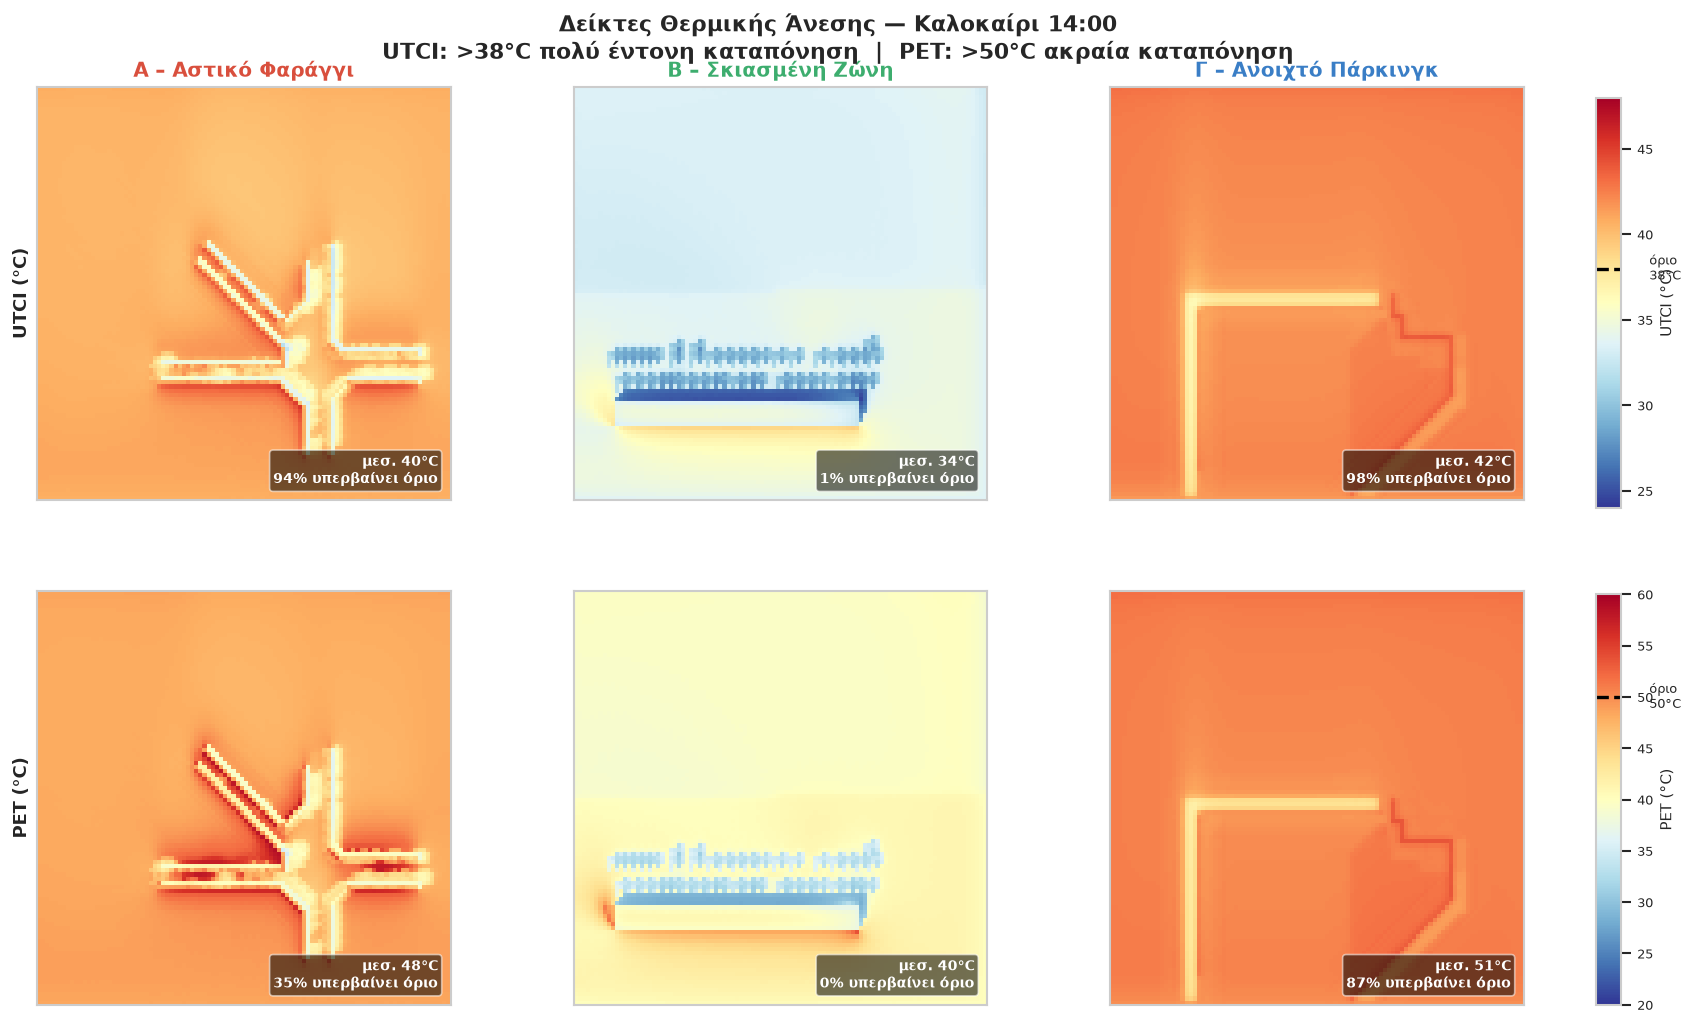

Saved G17


In [20]:
UTCI_COL = 'UTCI Biomet (°C)'
PET_COL  = 'PET* Default Person Biomet (°C)'

# UTCI stress thresholds (standard ISO categories)
UTCI_THRESHOLDS = {
    'Καμία καταπόνηση':      (9,  26,  '#92C5E8'),
    'Ήπια':                  (26, 32,  '#F9E79F'),
    'Έντονη':                (32, 38,  '#F0A500'),
    'Πολύ έντονη':           (38, 46,  '#E74C3C'),
    'Ακραία':                (46, 60,  '#7B241C'),
}

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.subplots_adjust(left=0.06, right=0.88, top=0.91, bottom=0.06,
                    wspace=0.07, hspace=0.22)
fig.suptitle('Δείκτες Θερμικής Άνεσης — Καλοκαίρι 14:00\n'
             'UTCI: >38°C πολύ έντονη καταπόνηση  |  PET: >50°C ακραία καταπόνηση',
             fontsize=13, fontweight='bold')

rows_cfg = [
    (UTCI_COL, 'RdYlBu_r', 24, 48, 'UTCI (°C)'),
    (PET_COL,  'RdYlBu_r', 20, 60, 'PET (°C)'),
]

for r, (col, cmap, vmin, vmax, row_label) in enumerate(rows_cfg):
    im = None
    for c, area in enumerate(AREA_ORDER):
        ax = axes[r, c]
        sub = srf[(srf['area'] == area) & (srf['date'] == '15Aug') & (srf['hour'] == 14)]

        if r == 0:
            ax.set_title(GR_AREA[area], fontsize=12, fontweight='bold',
                         color=AREA_COLORS[area])
        if c == 0:
            ax.set_ylabel(row_label, fontsize=11, fontweight='bold')

        if len(sub) == 0:
            ax.text(0.5, 0.5, '—', ha='center', va='center', transform=ax.transAxes)
            ax.set_xticks([]); ax.set_yticks([])
            continue

        grid = sub.pivot_table(index='j', columns='i', values=col, aggfunc='mean')
        im = ax.imshow(grid.values, origin='lower', cmap=cmap,
                       vmin=vmin, vmax=vmax, aspect='equal', interpolation='nearest')
        ax.set_xticks([]); ax.set_yticks([])

        med = sub[col].median()
        pct_extreme = (sub[col] > (38 if 'UTCI' in col else 50)).mean() * 100
        ax.text(0.97, 0.03,
                f'μεσ. {med:.0f}°C\n{pct_extreme:.0f}% υπερβαίνει όριο',
                transform=ax.transAxes, ha='right', va='bottom',
                fontsize=8.5, fontweight='bold', color='white',
                bbox=dict(boxstyle='round,pad=0.25', fc='black', alpha=0.55))

    if im is not None:
        cbar_ax = fig.add_axes([0.895, 0.06 + (1 - r) * 0.46, 0.013, 0.38])
        cb = fig.colorbar(im, cax=cbar_ax)
        cb.set_label(row_label, fontsize=9)
        cb.ax.tick_params(labelsize=8)
        # Mark stress threshold line
        threshold = 38 if 'UTCI' in col else 50
        cb.ax.axhline(threshold, color='black', lw=2, ls='--')
        cb.ax.text(1.8, threshold, f'  όριο\n  {threshold}°C',
                   va='center', fontsize=7.5, transform=cb.ax.get_yaxis_transform())

fig.savefig(SAVE_DIR / 'G17_UTCI_PET_spatial.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved G17')


## G18 — Nocturnal heat storage: surface temperature at 22:00 vs 06:00
Asphalt retains heat overnight — Areas A and C stay ~5°C warmer than B at night.  
Shows the urban heat island is not just a daytime phenomenon.

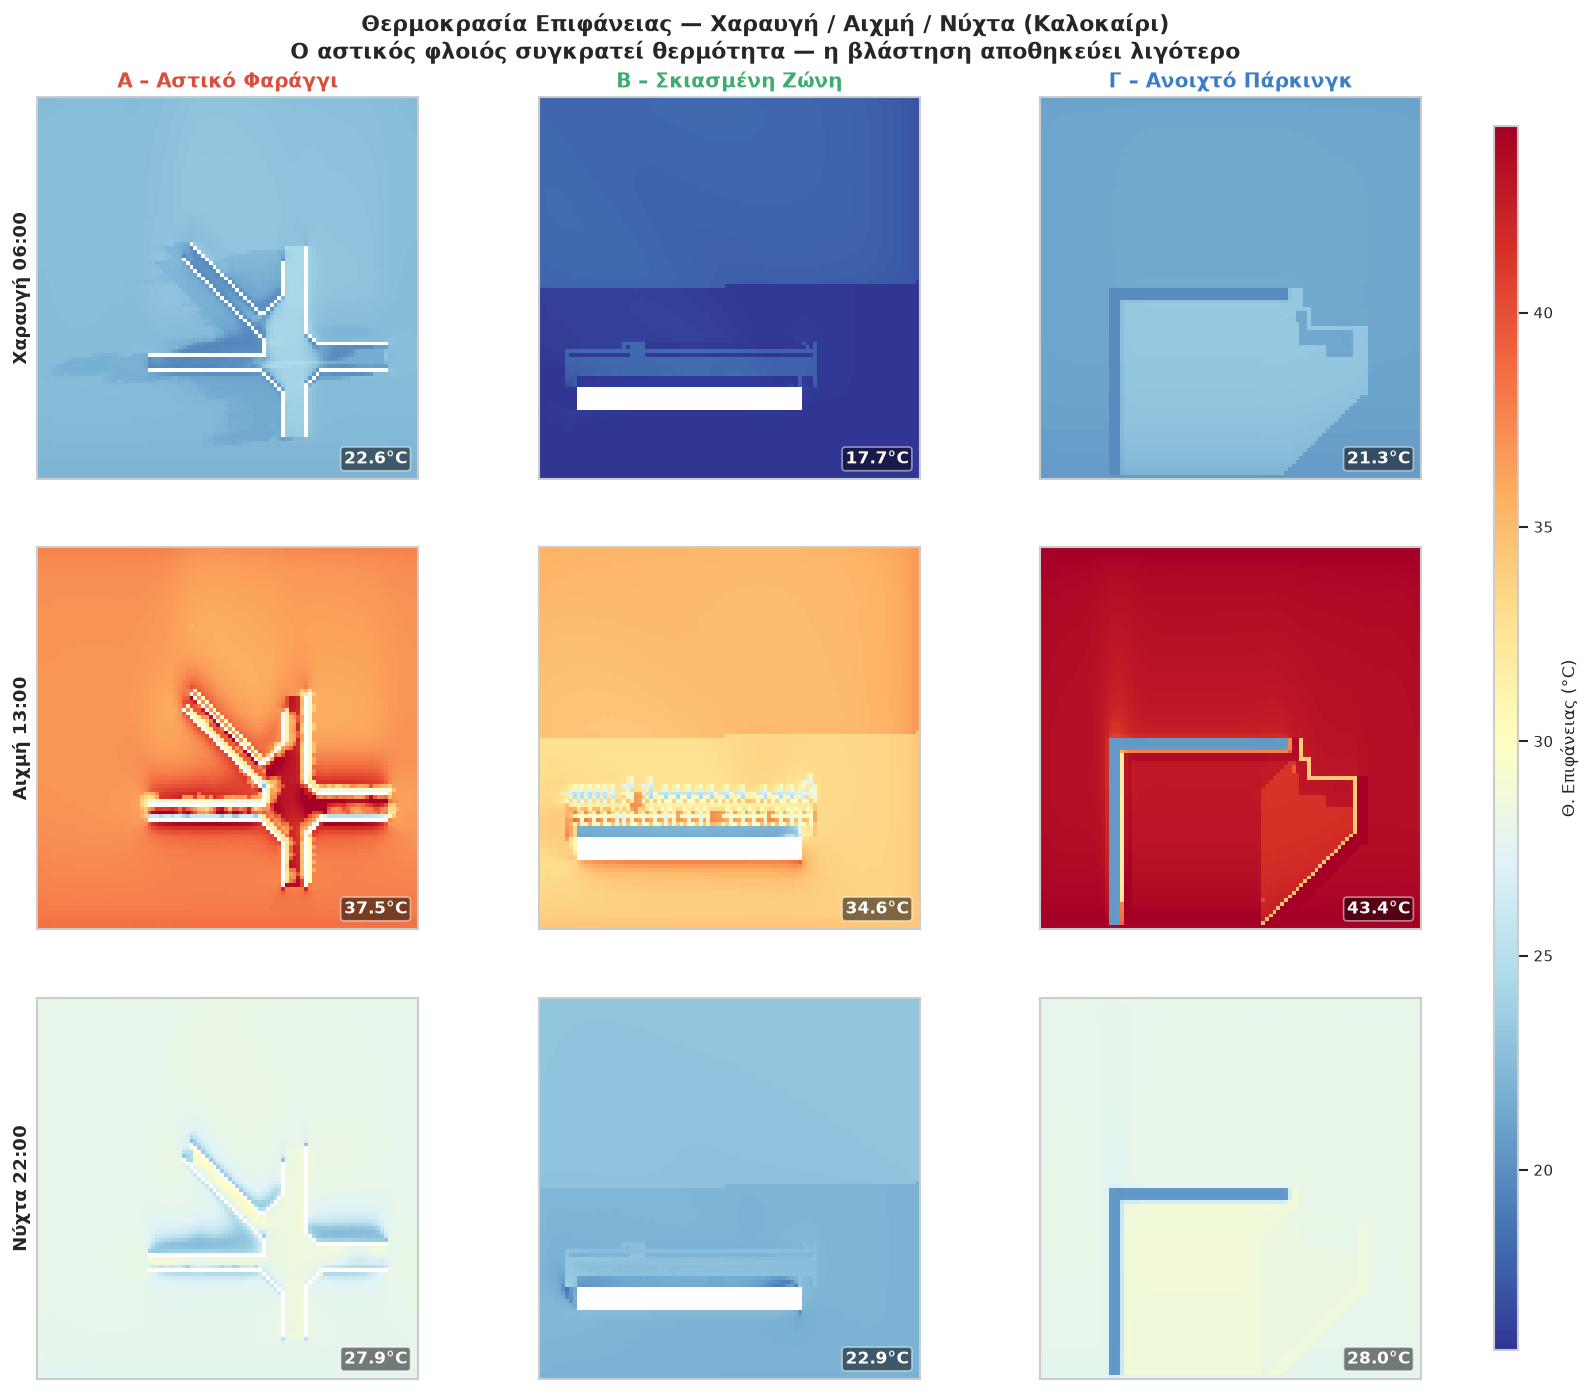

Saved G18


In [21]:
TIMEPOINTS = [(6, 'Χαραυγή 06:00'), (13, 'Αιχμή 13:00'), (22, 'Νύχτα 22:00')]

# Global colour scale across all hours
t_all = srf[(srf['date'] == '15Aug') & (srf['hour'].isin([h for h,_ in TIMEPOINTS]))][SURF_TEMP_COL].dropna()
vmin_t, vmax_t = t_all.quantile(0.02), t_all.quantile(0.98)

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
fig.subplots_adjust(left=0.07, right=0.89, top=0.92, bottom=0.03,
                    wspace=0.06, hspace=0.18)
fig.suptitle('Θερμοκρασία Επιφάνειας — Χαραυγή / Αιχμή / Νύχτα (Καλοκαίρι)\n'
             'Ο αστικός φλοιός συγκρατεί θερμότητα — η βλάστηση αποθηκεύει λιγότερο',
             fontsize=13, fontweight='bold')

im = None
for r, (hour, hour_label) in enumerate(TIMEPOINTS):
    for c, area in enumerate(AREA_ORDER):
        ax = axes[r, c]
        sub = srf[(srf['area'] == area) & (srf['date'] == '15Aug') & (srf['hour'] == hour)]

        if r == 0:
            ax.set_title(GR_AREA[area], fontsize=12, fontweight='bold',
                         color=AREA_COLORS[area])
        if c == 0:
            ax.set_ylabel(hour_label, fontsize=11, fontweight='bold')

        if len(sub) == 0:
            ax.text(0.5, 0.5, '—', ha='center', va='center', transform=ax.transAxes)
            ax.set_xticks([]); ax.set_yticks([])
            continue

        grid = sub.pivot_table(index='j', columns='i', values=SURF_TEMP_COL, aggfunc='mean')
        im = ax.imshow(grid.values, origin='lower', cmap='RdYlBu_r',
                       vmin=vmin_t, vmax=vmax_t, aspect='equal', interpolation='nearest')
        ax.set_xticks([]); ax.set_yticks([])

        med = sub[SURF_TEMP_COL].median()
        ax.text(0.97, 0.03, f'{med:.1f}°C',
                transform=ax.transAxes, ha='right', va='bottom',
                fontsize=10, fontweight='bold', color='white',
                bbox=dict(boxstyle='round,pad=0.2', fc='black', alpha=0.5))

if im is not None:
    cbar_ax = fig.add_axes([0.905, 0.05, 0.013, 0.85])
    cb = fig.colorbar(im, cax=cbar_ax)
    cb.set_label('Θ. Επιφάνειας (°C)', fontsize=10)
    cb.ax.tick_params(labelsize=9)

fig.savefig(SAVE_DIR / 'G18_surface_temp_day_cycle.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved G18')


## G19 — Latent Heat Flux spatial map (summer 14:00)
LE > 0 = active evapotranspiration. Most cells in all areas have LE ≈ 0.  
Only specific vegetated patches actively cool — the spatial map reveals exactly which ones.

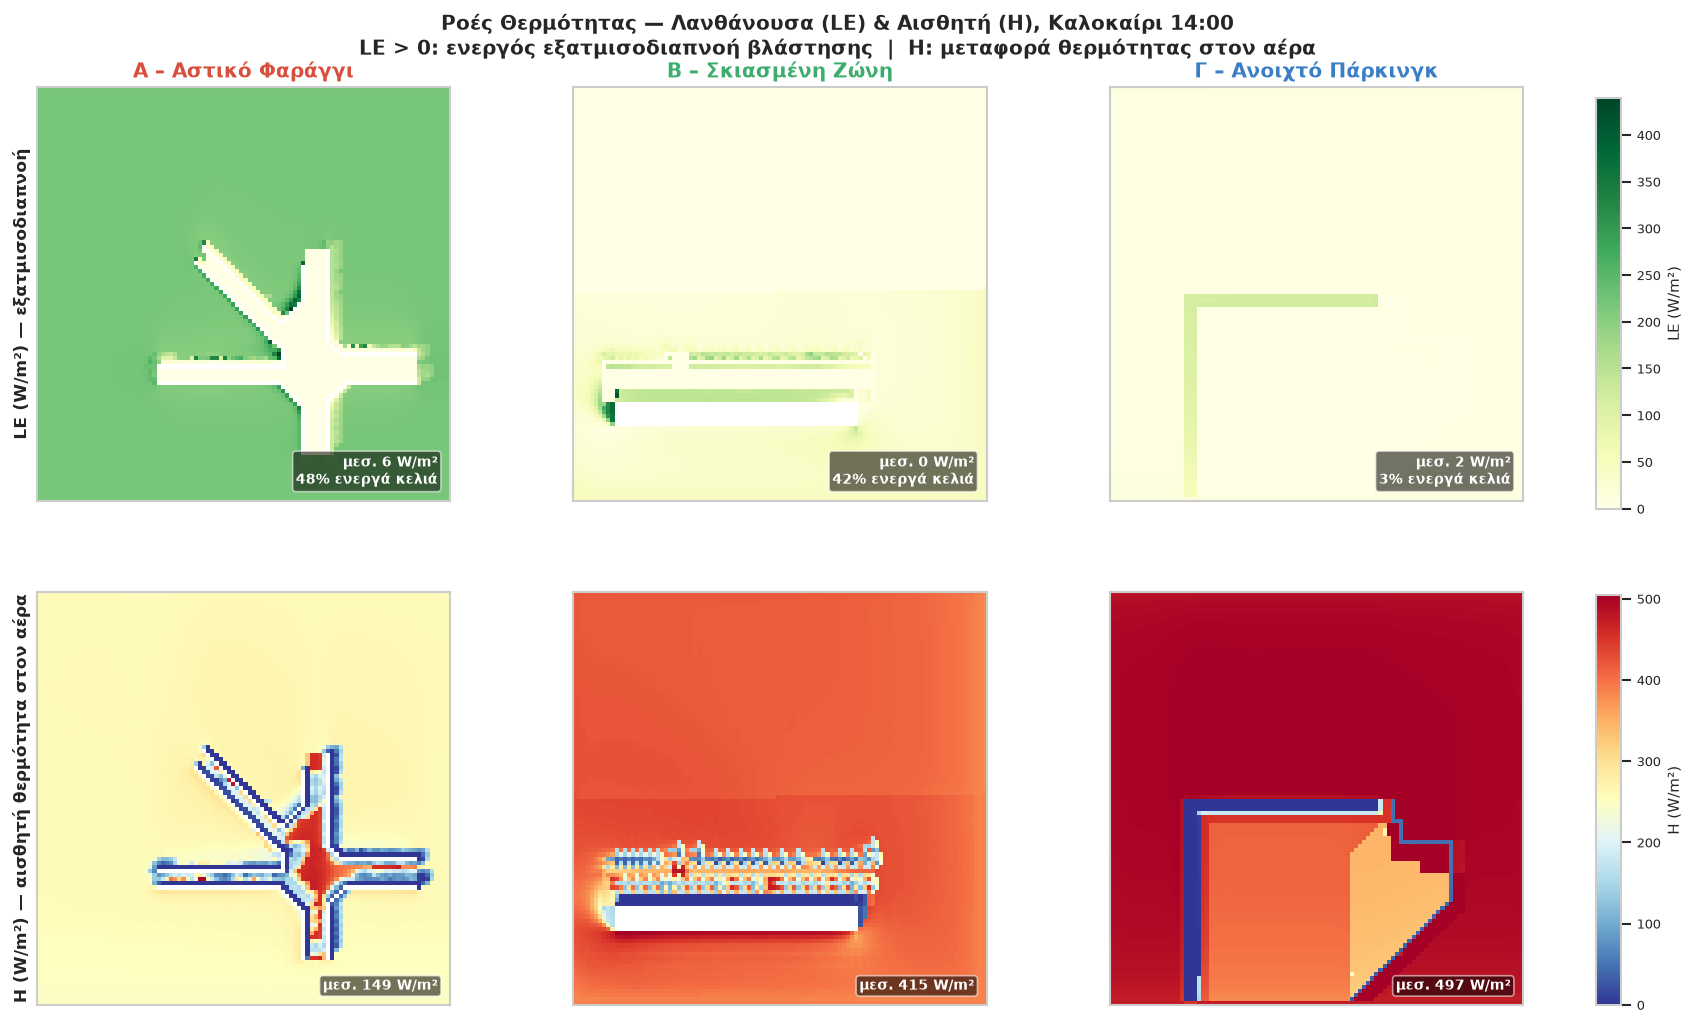

Saved G19


In [22]:
LE_COL = 'Latent Heat Flux LE (W/m2)'
H_COL  = 'Sensible Heat Flux H (W/m2)'

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.subplots_adjust(left=0.06, right=0.88, top=0.91, bottom=0.06,
                    wspace=0.07, hspace=0.22)
fig.suptitle('Ροές Θερμότητας — Λανθάνουσα (LE) & Αισθητή (H), Καλοκαίρι 14:00\n'
             'LE > 0: ενεργός εξατμισοδιαπνοή βλάστησης  |  H: μεταφορά θερμότητας στον αέρα',
             fontsize=12, fontweight='bold')

# Global scales
le_vals = srf[(srf['date'] == '15Aug') & (srf['hour'] == 14)][LE_COL].dropna()
h_vals  = srf[(srf['date'] == '15Aug') & (srf['hour'] == 14)][H_COL].dropna()
le_max  = le_vals.quantile(0.98)
h_min, h_max = h_vals.quantile(0.02), h_vals.quantile(0.98)

rows_flux = [
    (LE_COL, 'YlGn',    0,     le_max, 'LE (W/m²) — εξατμισοδιαπνοή'),
    (H_COL,  'RdYlBu_r', h_min, h_max,  'H (W/m²) — αισθητή θερμότητα στον αέρα'),
]

for r, (col, cmap, vmin, vmax, row_label) in enumerate(rows_flux):
    im = None
    for c, area in enumerate(AREA_ORDER):
        ax = axes[r, c]
        sub = srf[(srf['area'] == area) & (srf['date'] == '15Aug') & (srf['hour'] == 14)]

        if r == 0:
            ax.set_title(GR_AREA[area], fontsize=12, fontweight='bold',
                         color=AREA_COLORS[area])
        if c == 0:
            ax.set_ylabel(row_label, fontsize=10, fontweight='bold')

        if len(sub) == 0:
            ax.text(0.5, 0.5, '—', ha='center', va='center', transform=ax.transAxes)
            ax.set_xticks([]); ax.set_yticks([])
            continue

        grid = sub.pivot_table(index='j', columns='i', values=col, aggfunc='mean')
        im = ax.imshow(grid.values, origin='lower', cmap=cmap,
                       vmin=vmin, vmax=vmax, aspect='equal', interpolation='nearest')
        ax.set_xticks([]); ax.set_yticks([])

        med = sub[col].median()
        pct_active = (sub[col] > 10).mean() * 100 if col == LE_COL else None
        label = f'μεσ. {med:.0f} W/m²'
        if pct_active is not None:
            label += f'\n{pct_active:.0f}% ενεργά κελιά'
        ax.text(0.97, 0.03, label,
                transform=ax.transAxes, ha='right', va='bottom',
                fontsize=8.5, fontweight='bold', color='white',
                bbox=dict(boxstyle='round,pad=0.22', fc='black', alpha=0.55))

    if im is not None:
        cbar_ax = fig.add_axes([0.895, 0.06 + (1 - r) * 0.46, 0.013, 0.38])
        cb = fig.colorbar(im, cax=cbar_ax)
        cb.set_label(row_label.split('—')[0].strip(), fontsize=9)
        cb.ax.tick_params(labelsize=8)

fig.savefig(SAVE_DIR / 'G19_LE_H_flux_spatial.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved G19')


## G20 — Diurnal heatmap: spatial position × hour of day (summer)
Each column = one hour. Each row = a N–S strip of the grid (j position, averaged across E–W).  
Colour = value at that location at that time.  
**Canyon (Area A):** shadow bands visibly migrate as the sun moves — direct visual proof of urban morphology effect.

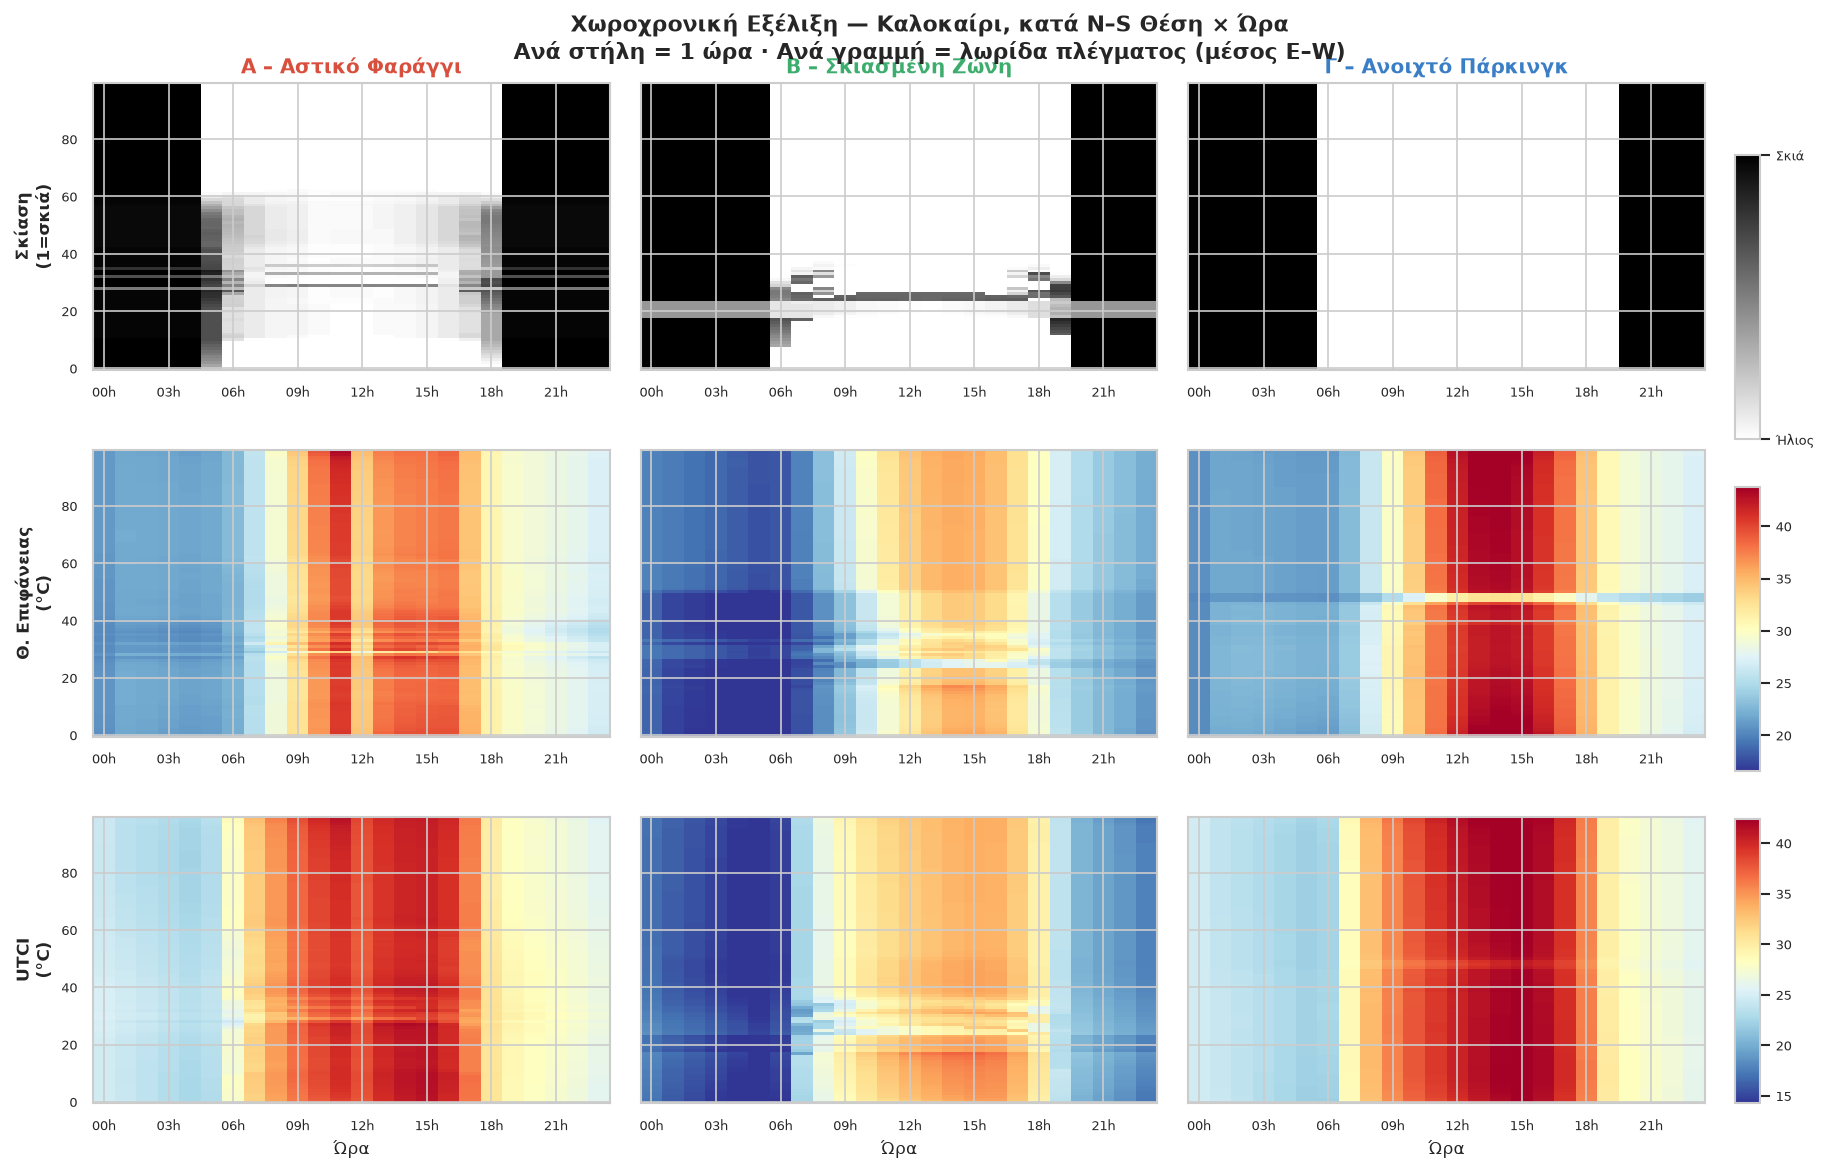

Saved G20


In [23]:
ROWS_D = [
    (SHADOW_COL,    'binary',    0,    1,    'Σκίαση\n(1=σκιά)'),
    (SURF_TEMP_COL, 'RdYlBu_r', None, None, 'Θ. Επιφάνειας\n(°C)'),
    (UTCI_COL,      'RdYlBu_r', None, None, 'UTCI\n(°C)'),
]

# Global scales from summer data across all areas
for idx, (col, cmap, vmin, vmax, lbl) in enumerate(ROWS_D):
    if vmin is None:
        vals = srf[(srf['date'] == '15Aug')][col].dropna()
        ROWS_D[idx] = (col, cmap, vals.quantile(0.02), vals.quantile(0.98), lbl)

hours_all = sorted(srf['hour'].unique())

fig, axes = plt.subplots(len(ROWS_D), len(AREA_ORDER),
                          figsize=(17, 10), sharey='row')
fig.subplots_adjust(left=0.09, right=0.88, top=0.92, bottom=0.07,
                    wspace=0.06, hspace=0.28)
fig.suptitle('Χωροχρονική Εξέλιξη — Καλοκαίρι, κατά N–S Θέση × Ώρα\n'
             'Ανά στήλη = 1 ώρα · Ανά γραμμή = λωρίδα πλέγματος (μέσος E–W)',
             fontsize=13, fontweight='bold')

for c, area in enumerate(AREA_ORDER):
    sub_area = srf[(srf['area'] == area) & (srf['date'] == '15Aug')]

    for r, (col, cmap, vmin, vmax, row_label) in enumerate(ROWS_D):
        ax = axes[r, c]

        # Average across i (E–W) → keeps j (N–S) and hour
        pivot = (sub_area.groupby(['hour', 'j'])[col]
                         .mean()
                         .unstack('j'))          # shape: hours × j-positions
        # Transpose: rows=j (y-axis), cols=hour (x-axis)
        mat = pivot.T.values

        im = ax.imshow(mat, aspect='auto', cmap=cmap,
                       vmin=vmin, vmax=vmax,
                       origin='lower', interpolation='nearest')

        # X-axis: hours
        ax.set_xticks(range(0, len(hours_all), 3))
        ax.set_xticklabels([f'{hours_all[i]:02d}h' for i in range(0, len(hours_all), 3)],
                           fontsize=8)
        ax.tick_params(axis='y', labelsize=8)

        # Labels
        if r == 0:
            ax.set_title(GR_AREA[area], fontsize=12, fontweight='bold',
                         color=AREA_COLORS[area])
        if c == 0:
            ax.set_ylabel(row_label, fontsize=10, fontweight='bold')
        if r == len(ROWS_D) - 1:
            ax.set_xlabel('Ώρα', fontsize=10)

        # Colourbar (right side, one per row)
        if c == len(AREA_ORDER) - 1:
            cbar_ax = fig.add_axes([
                0.895,
                0.07 + (len(ROWS_D) - 1 - r) * (0.83 / len(ROWS_D)),
                0.012,
                0.83 / len(ROWS_D) - 0.04
            ])
            cb = fig.colorbar(im, cax=cbar_ax)
            cb.ax.tick_params(labelsize=8)
            if col == SHADOW_COL:
                cb.set_ticks([0, 1])
                cb.set_ticklabels(['Ήλιος', 'Σκιά'])

fig.savefig(SAVE_DIR / 'G20_diurnal_spatial_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved G20')
